# Experiment 1: proof-of-concept solution-driven models

In [1]:
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import os
import pickle
import glob 
import itertools
import ast


import json
from scipy.stats import ttest_rel, wilcoxon
from collections import Counter
import ast
from collections import deque
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.patches as patches
import math
from copy import deepcopy
import pickle
import heapq
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from patsy import dmatrix, build_design_matrices  # <- key import
from scipy.spatial.distance import cdist, jensenshannon
from scipy.optimize import linprog

import models.mdps as mdps
import models.jit as jit



start_goal_pos = [(8,1),(8,15)]

figpath = os.path.join("fig")
fitspath = os.path.join("model_traces")
data_savepath = os.path.join("data")
datapath = os.path.join("..","experiment","data", "exp1")

In [2]:
import ast
import heapq
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy import stats

def annotate_paired(
    ax, df, x, y, hue=None, pairs=None,
    order=None, hue_order=None,
    cat_width=0.8,       # match seaborn's violinplot width
    text_offset=0.06,    # fraction of y-range between brackets
    linewidth=1.2, fontsize=15,
    label='stars',       # 'stars' | 'p' | 'p_and_d'
    test_type = "paired-t", # "paired-t" | "wilcoxon"
    print_table=True,    # print a table of results
    return_table=False,  # return the results DataFrame
    decimals=3           # rounding in printed table
):
    """
    Draw paired t-test brackets and (optionally) print/return stats.
    If hue is None: pairs = [(x1, x2), ...]
    If hue is not None: pairs = [((x1,h1),(x2,h2)), ...]

    Effect size reported: Cohen's dz = mean(diff)/sd(diff), paired design.
    """
    # Ensure Subject column for pairing
    if 'Subj' not in df.columns:
        df = df.reset_index()

    # Resolve plotting orders
    if order is None:
        order = list(pd.unique(df[x]))
    if hue is not None and hue_order is None:
        hue_order = list(pd.unique(df[hue]))

    # ---- centers that match split-violins exactly ----
    if hue is None:
        offset_map = {None: 0.0}
    else:
        k = len(hue_order)
        cell = cat_width / float(k)  # width per split violin
        centers = np.linspace(-cat_width/2 + cell/2,
                              +cat_width/2 - cell/2, k)
        offset_map = {h: centers[i] for i, h in enumerate(hue_order)}

    def xpos(x_level, h_level=None):
        xi = order.index(x_level)
        return xi + (offset_map[None] if hue is None else offset_map[h_level])

    # ---- compute stats for each pair ----
    rows = []
    for pr in pairs:
        if hue is None:
            x1, x2 = pr
            d1 = df[df[x] == x1][['Subj', y]].rename(columns={y:'v1'})
            d2 = df[df[x] == x2][['Subj', y]].rename(columns={y:'v2'})
            lab = f"{x} {x1} vs {x2}"
        else:
            (x1, h1), (x2, h2) = pr
            d1 = df[(df[x] == x1) & (df[hue] == h1)][['Subj', y]].rename(columns={y:'v1'})
            d2 = df[(df[x] == x2) & (df[hue] == h2)][['Subj', y]].rename(columns={y:'v2'})
            lab = f"({x1},{h1}) vs ({x2},{h2})"

        merged = pd.merge(d1, d2, on='Subj').dropna(subset=['v1','v2'])
        n = len(merged)
        if n >= 2:
            diff = (merged['v1'] - merged['v2']).to_numpy(dtype=float)
            sd = np.std(diff, ddof=1)
            dz = np.nan if sd == 0 else np.mean(diff) / sd
            if(test_type=="paired-t"):
                t_stat, p = ttest_rel(merged['v1'], merged['v2'])
            elif(test_type=="wilcoxon"):
                t_stat, p = wilcoxon(merged['v1'], merged['v2'])
            dfree = n - 1
        else:
            t_stat = p = dz = np.nan
            dfree = n - 1

        rows.append({
            'comparison': lab, 'n': n, 'df': dfree,
            't': t_stat, 'p': p, 'cohen_dz': dz
        })

    results = pd.DataFrame(rows)

    # ---- vertical layout & draw ----
    ymin, ymax = ax.get_ylim()
    yr = max(ymax - ymin, 1e-9)
    step = text_offset * yr
    ax.set_ylim(ymin, ymax + step * (len(pairs)*3 + 1))

    for i, pr in enumerate(pairs):
        if hue is None:
            x1, x2 = pr
            x1p, x2p = xpos(x1), xpos(x2)
        else:
            (x1, h1), (x2, h2) = pr
            x1p, x2p = xpos(x1, h1), xpos(x2, h2)

        stats = results.iloc[i]
        p = stats['p']; dz = stats['cohen_dz']

        # label text
        if label == 'stars':
            if   np.isnan(p): s = 'n/a'
            elif p < 1e-4:    s = "****"
            elif p < 1e-3:    s = '***'
            elif p < 1e-2:    s = '**'
            elif p < 5e-2:    s = '*'
            else:             s = 'n.s.'
        elif label == 'p':
            s = f"p={p:.3g}" if not np.isnan(p) else "p=n/a"
        elif label == 'p_and_d':
            sp = f"p={p:.3g}" if not np.isnan(p) else "p=n/a"
            sd = f"dᶻ={dz:.2f}" if not np.isnan(dz) else "dᶻ=n/a"
            s = sp + "\n" + sd
        else:
            s = ''

        # bracket height for this pair
        yb = ymax + step * (i*3 + 1)
        ytop = yb + step

        ax.plot([x1p, x1p, x2p, x2p], [yb, ytop, ytop, yb],
                'k-', lw=linewidth, clip_on=False)
        ax.text((x1p+x2p)/2.0, ytop + 0.12*step, s,
                ha='center', va='bottom', fontsize=fontsize, clip_on=False)

    # ---- print & return ----
    if print_table:
        with pd.option_context('display.float_format', lambda v: f"{v:.{decimals}f}"):
            print(results.to_string(index=False))

    if return_table:
        return results

        


def annotate_violin_significance(
    ax,
    df,
    x, y,
    hue=None,
    test="t",             # "t" for one-sample t-test, "wilcoxon" for signed-rank
    mu=0,
    show="stars",         # "stars", "p", or "p_and_d"
    fmt="%.4g",           # format for p-values if show="p" or show="p_and_d"
    d_fmt="%.2f",         # format for Cohen's d if show="p_and_d"
    y_offset=0.02,
    min_height_pad=0.1,
    zero_method="wilcox",
    alternative="two-sided",
    fontsize=15,
    width=0.8,
    debug=False
):
    """
    Robustly annotate a seaborn violinplot (with or without hue) with significance vs. mu.

    show:
        "stars"   -> significance stars
        "p"       -> p-value
        "p_and_d" -> p-value plus one-sample Cohen's d

    Effect size:
        Cohen's d = (mean(group) - mu) / sd(group)
    """

    def infer_levels(series):
        if isinstance(series.dtype, pd.CategoricalDtype):
            return list(series.cat.categories)
        vals = series.dropna().unique().tolist()
        try:
            return sorted(vals)
        except Exception:
            return vals

    def p_to_stars(p):
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 5e-2: return "*"
        return "n.s."

    def cohen_d_onesample(group, mu=0):
        group = np.asarray(group, dtype=float)
        group = group[~np.isnan(group)]
        if group.size < 2:
            return np.nan
        sd = np.std(group, ddof=1)
        if sd == 0:
            return np.nan
        return (np.mean(group) - mu) / sd

    # 1) Establish plotting order for x and hue
    xticks = np.array(ax.get_xticks())
    xticklabels = [t.get_text() for t in ax.get_xticklabels()]
    if any(lbl != "" for lbl in xticklabels) and len(xticklabels) == len(xticks):
        x_levels = xticklabels
        unique_x_vals = list(dict.fromkeys(df[x].dropna().tolist()))
        x_resolver = {str(v): v for v in unique_x_vals}
        x_levels = [x_resolver.get(lbl, lbl) for lbl in x_levels]
    else:
        x_levels = infer_levels(df[x])
        xticks = np.arange(len(x_levels))

    if hue is None:
        hue_levels = [None]
    else:
        hue_levels = infer_levels(df[hue])
        try:
            _, leglabels = ax.get_legend_handles_labels()
            data_hue_str = {str(v) for v in df[hue].dropna().unique().tolist()}
            leglabels = [lab for lab in leglabels if lab in data_hue_str]
            if len(leglabels) == len(hue_levels):
                hue_map = {str(v): v for v in df[hue].dropna().unique().tolist()}
                hue_levels = [hue_map.get(lab, lab) for lab in leglabels]
        except Exception:
            pass

    n_x = len(x_levels)
    n_h = len(hue_levels)

    # 2) Detect violin centers and tops
    polys = [c for c in ax.findobj(PolyCollection)]
    centers_by_x = [dict() for _ in range(n_x)]

    for poly in polys:
        paths = getattr(poly, "get_paths", lambda: [])()
        if not paths:
            continue
        verts = paths[0].vertices
        if verts.size == 0:
            continue
        cx = float(np.mean(verts[:, 0]))
        ty = float(np.max(verts[:, 1]))
        x_idx = int(np.argmin(np.abs(xticks - cx)))
        key = round(cx, 6)
        centers_by_x[x_idx][key] = max(ty, centers_by_x[x_idx].get(key, -np.inf))

    # 3) Build mapping from condition to violin center/top
    center_map = {}
    top_map = {}

    for xi, xv in enumerate(x_levels):
        present_centers = sorted(centers_by_x[xi].items(), key=lambda kv: kv[0])

        if len(present_centers) == n_h:
            for hj, hv in enumerate(hue_levels):
                cx, ty = present_centers[hj]
                center_map[(xv, hv)] = cx
                top_map[(xv, hv)] = ty
        else:
            if debug:
                print(f"[annotate_violin_significance] Fallback at x={xv}: "
                      f"found {len(present_centers)} centers, expected {n_h}.")
            tick_center = xticks[xi]
            offsets = np.linspace(
                -width/2 + width/(2*n_h),
                width/2 - width/(2*n_h),
                n_h
            ) if n_h > 1 else np.array([0.0])

            ty_guess = df.loc[df[x] == xv, y].max()
            for hj, hv in enumerate(hue_levels):
                center_map[(xv, hv)] = tick_center + offsets[hj]
                top_map[(xv, hv)] = float(ty_guess)

    # 4) Run tests and compute Cohen's d
    global_y_max = float(np.nanmax(df[y].values))

    annotations = []
    for xv in x_levels:
        for hv in hue_levels:
            if hue is None:
                mask = (df[x] == xv)
            else:
                mask = (df[x] == xv) & (df[hue] == hv)

            group = df.loc[mask, y].dropna().values

            if group.size == 0:
                pval = np.nan
                dval = np.nan
            else:
                dval = cohen_d_onesample(group, mu=mu)

                if test.lower() in ["t", "ttest", "t-test", "onesample", "one-sample"]:
                    res = stats.ttest_1samp(group, popmean=mu, alternative=alternative)
                    pval = res.pvalue

                elif test.lower() in ["wilcoxon", "signed-rank", "wilcox"]:
                    diffs = group - mu
                    if np.allclose(diffs, 0):
                        pval = 1.0
                    else:
                        res = stats.wilcoxon(
                            diffs,
                            zero_method=zero_method,
                            alternative=alternative,
                            method="auto"
                        )
                        pval = res.pvalue
                else:
                    raise ValueError("test must be 't' or 'wilcoxon'")

            annotations.append((xv, hv, pval, dval))

    # 5) Draw annotations
    for xv, hv, pval, dval in annotations:
        cx = center_map[(xv, hv)]
        ty = top_map[(xv, hv)]
        y_text = max(ty + y_offset, global_y_max + min_height_pad)

        if np.isnan(pval):
            label = "n/a"
        elif show == "stars":
            label = p_to_stars(pval)
        elif show == "p":
            label = f"p={fmt % pval}"
        elif show == "p_and_d":
            p_txt = f"p={fmt % pval}"
            d_txt = f"d={d_fmt % dval}" if not np.isnan(dval) else "d=n/a"
            label = p_txt + "\n" + d_txt
        else:
            raise ValueError("show must be 'stars', 'p', or 'p_and_d'")

        ax.text(
            cx, y_text, label,
            ha="center", va="bottom",
            fontsize=fontsize,
            clip_on=False
        )

    ax.set_ylim(
        bottom=ax.get_ylim()[0],
        top=max(ax.get_ylim()[1], global_y_max + 0.08)
    )

    return ax

def reset_numeric_xticklabels_for_annotation(ax, order):
    """
    Temporarily make x tick labels match the dataframe values,
    so annotate_violin_significance can find df[x] == 0 / 1.
    """
    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels([str(v) for v in order])
    
# -----------------------------
# Basic parsing helpers
# -----------------------------
def _maybe_literal_eval(x):
    """Safely parse strings like '[8,1]' or "['....', '.##.']"."""
    if isinstance(x, str):
        x = x.strip()
        try:
            return ast.literal_eval(x)
        except Exception:
            return x
    return x


def parse_point(pt):
    """
    Convert a start/goal entry into a tuple (col, row).
    Accepts:
      - [c, r]
      - (c, r)
      - string versions of the above
    """
    pt = _maybe_literal_eval(pt)
    if isinstance(pt, (list, tuple)) and len(pt) == 2:
        return (int(pt[0]), int(pt[1]))
    raise ValueError(f"Could not parse point: {pt}")


def parse_maze_grid(maze):
    """
    Convert maze_grid entry into List[str].
    Accepts:
      - list of strings
      - tuple of strings
      - string representation of list/tuple
    """
    maze = _maybe_literal_eval(maze)

    if isinstance(maze, (list, tuple)):
        maze = [str(row) for row in maze]
        if len(set(len(r) for r in maze)) != 1:
            raise ValueError("Maze rows are not all the same length.")
        return maze

    raise ValueError(f"Could not parse maze_grid: {maze}")


# -----------------------------
# Greedy best-first search
# -----------------------------
def solve_maze_BestFirstSearch(
    maze,
    start=None,
    end=None,
    heuristic="Manhattan",
):
    """
    Perform greedy best-first search on a rectangular maze.

    Parameters
    ----------
    maze : List[str]
        Maze represented as a list of strings of equal length.
        '#' = wall, everything else treated as traversible.
    start : (col, row)
    end : (col, row)
    heuristic : {"Manhattan", "Euclidean"}

    Returns
    -------
    result : dict with keys
        path : List[(col, row)]
        evaluated : List[(col, row)]
        walls : List[(col, row)]
        search_cost : int
        search_found : int
    """
    width = len(maze[0])
    height = len(maze)

    if start is None or end is None:
        raise ValueError("Please provide explicit start and end coordinates.")

    def h(cell):
        c, r = cell
        gc, gr = end
        if heuristic == "Manhattan":
            return abs(c - gc) + abs(r - gr)
        elif heuristic == "Euclidean":
            return np.sqrt((c - gc) ** 2 + (r - gr) ** 2)
        else:
            raise ValueError(f"Unknown heuristic: {heuristic}")

    frontier = [(h(start), start)]
    came_from = {start: None}
    visited = {start}
    evaluated = []
    walls = []

    while frontier:
        _, current = heapq.heappop(frontier)
        evaluated.append(current)

        if current == end:
            break

        c, r = current
        for dc, dr in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nc, nr = c + dc, r + dr
            if not (0 <= nc < width and 0 <= nr < height):
                continue

            neighbor = (nc, nr)
            if neighbor in visited:
                continue

            if maze[nr][nc] == "#":
                walls.append(neighbor)
                continue

            visited.add(neighbor)
            came_from[neighbor] = current
            heapq.heappush(frontier, (h(neighbor), neighbor))

    path = []
    if end in came_from:
        node = end
        while node is not None:
            path.append(node)
            node = came_from[node]
        path.reverse()

    search_found = int(len(path) > 0)
    search_cost = len(evaluated) + len(walls)

    return {
        "path": path,
        "evaluated": evaluated,
        "walls": walls,
        "search_cost": search_cost,
        "search_found": search_found,
    }


# -----------------------------
# Classify the BFS path
# -----------------------------
def classify_search_solution_slot(path, left_rim_path, right_rim_path):
    """
    Map a BFS path to:
      0 = left rim solution
      1 = right rim solution
     -1 = neither rim (interior / other)
    """
    if len(path) == 0:
        return 0

    path_set = set(path)

    if path_set.issubset(left_rim_path):
        return 1
    elif path_set.issubset(right_rim_path):
        return 2
    else:
        return 0

def convert_human_solution_slot(x):
    """
    Convert human column path_taken_on_leftorrightrim
    to NumPyro slot convention.
    """
    if x == -1:
        return 0
    elif x == 0:
        return 1
    elif x == 1:
        return 2
    else:
        return 0
    
# -----------------------------
# Main preprocessing function
# -----------------------------
def add_exp1a_precomputations(
    df_human_modeling,
    left_rim_path,
    right_rim_path,
    heuristic="Manhattan",
    add_obs_solution_slot=True,
):
    """
    Add trialwise precomputations for Experiment 1a.

    Parameters
    ----------
    df_human_modeling : pd.DataFrame
        Must contain at least:
            maze_grid
            start_pos
            goal_pos
            left_rim_path_open
            right_rim_path_open
        Optionally:
            path_taken_on_leftorrightrim
    left_rim_path : set of (col, row)
    right_rim_path : set of (col, row)
    heuristic : str
    add_obs_solution_slot : bool
        If True, also add an obs_solution_slot column based on
        path_taken_on_leftorrightrim.

    Returns
    -------
    df_out : pd.DataFrame
        Copy of input dataframe with added columns.
    """
    df = df_human_modeling.copy()

    search_paths = []
    search_costs = []
    search_founds = []
    search_solution_slots = []

    cache_masks = []
    cache_valids = []

    for _, row in df.iterrows():
        maze = parse_maze_grid(row["maze_grid"])
        start = parse_point(row["start_pos"])
        goal = parse_point(row["goal_pos"])

        bfs = solve_maze_BestFirstSearch(
            maze=maze,
            start=start,
            end=goal,
            heuristic=heuristic,
        )

        path = bfs["path"]
        search_cost = bfs["search_cost"]
        search_found = bfs["search_found"]
        search_solution_slot = classify_search_solution_slot(
            path=path,
            left_rim_path=left_rim_path,
            right_rim_path=right_rim_path,
        )

        # In this first-level Exp 1a model, the two reusable solution slots
        # always exist as candidate cache entries.
        cache_mask = [1, 1]

        # Objective validity of the two cached solutions on this trial.
        cache_valid = [
            int(row["left_rim_path_open"]),
            int(row["right_rim_path_open"]),
        ]

        search_paths.append(path)
        search_costs.append(search_cost)
        search_founds.append(search_found)
        search_solution_slots.append(search_solution_slot)

        cache_masks.append(cache_mask)
        cache_valids.append(cache_valid)

    df["search_path"] = search_paths
    df["search_cost"] = search_costs
    df["search_found"] = search_founds
    df["search_solution_slot"] = search_solution_slots

    df["cache_mask"] = cache_masks
    df["cache_valid"] = cache_valids

    # Optional convenience column from the human submission itself:
    #   0 = left rim submitted
    #   1 = right rim submitted
    #  -1 = interior path / search-like non-rim solution
    if add_obs_solution_slot and "path_taken_on_leftorrightrim" in df.columns:
        df["obs_solution_slot"] = df["path_taken_on_leftorrightrim"].apply(
            convert_human_solution_slot
        )

    return df

## Numpyro model

In [3]:

def build_two_full_rim_routes(max_coord=16):
    """
    Construct the two canonical full rim routes.

    Entry point on rim:  (8, 0)
    Exit point near goal: (8, 14)

    Route A:
      (8,0) -> left along top edge to (0,0)
             -> down left edge to (0,16)
             -> right along bottom edge to (8,16)

    Route B:
      (8,0) -> right along top edge to (16,0)
             -> down right edge to (16,16)
             -> left along bottom edge to (8,16)

    Returns
    -------
    route_left, route_right : sets of (x, y)
    """
    # Left route
    route_left = set()

    # top edge: (8,0) -> (0,0)
    for x in range(0, 9):
        route_left.add((x, 0))

    # left edge: (0,0) -> (0,16)
    for y in range(0, max_coord + 1):
        route_left.add((0, y))

    # bottom edge: (0,16) -> (8,16)
    for x in range(0, 9):
        route_left.add((x, max_coord))

    # Right route
    route_right = set()

    # top edge: (8,0) -> (16,0)
    for x in range(8, max_coord + 1):
        route_right.add((x, 0))

    # right edge: (16,0) -> (16,16)
    for y in range(0, max_coord + 1):
        route_right.add((max_coord, y))

    # bottom edge: (16,16) -> (8,16)
    for x in range(8, max_coord + 1):
        route_right.add((x, max_coord))

    return route_left, route_right

left_rim_path, right_rim_path = build_two_full_rim_routes(max_coord=16)
left_rim_path = left_rim_path|set(start_goal_pos)
right_rim_path = right_rim_path|set(start_goal_pos)
rim_path_length = len(left_rim_path)

In [4]:

def prepare_numpyro_inputs(
    df_subject_block: pd.DataFrame,
    subj_col: str = "subj_idx",
    cond_col: str = "cond",
    cache_mask_col: str = "cache_mask",
    cache_valid_col: str = "cache_valid",
    search_path_len_col: str = "search_path_len",
    search_cost_col: str = "search_cost",
    search_found_col: str = "search_found",
    search_solution_slot_col: str = "search_solution_slot",
    obs_solution_slot_col: str = "obs_solution_slot",
    sort_by=("subj_idx","block", "trial"),
    return_metadata: bool = True,
):
    """
    Convert one subject dataframe into NumPy arrays for the NumPyro model.

    Critical:
    ---------
    Trials are sorted in true temporal order, defaulting to:
        block -> trial

    Label convention:
        0 = search
        1 = reuse left
        2 = reuse right
    """
    df = df_subject_block.copy()

    if len(df) == 0:
        raise ValueError("df_subject_block is empty.")

    missing_sort = [c for c in sort_by if c not in df.columns]
    if missing_sort:
        raise ValueError(f"Missing sort columns: {missing_sort}")
    df = df.sort_values(list(sort_by)).reset_index(drop=True)

    required = [
        subj_col,
        cond_col,
        cache_mask_col,
        cache_valid_col,
        search_path_len_col,
        search_cost_col,
        search_found_col,
        search_solution_slot_col,
        obs_solution_slot_col,
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Condition mapping: smaller value -> 0, larger value -> 1
    cond_vals = pd.unique(df[cond_col])
    cond_vals = [x for x in cond_vals if pd.notnull(x)]
    if len(cond_vals) == 0:
        raise ValueError(f"No non-null values found in '{cond_col}'.")

    cond_vals_sorted = sorted(cond_vals)
    if len(cond_vals_sorted) == 1:
        cond_map = {cond_vals_sorted[0]: 0}
    elif len(cond_vals_sorted) == 2:
        cond_map = {
            cond_vals_sorted[0]: 0,
            cond_vals_sorted[1]: 1,
        }
    else:
        raise ValueError(
            f"Expected 1 or 2 unique condition values in '{cond_col}', got {cond_vals_sorted}."
        )

    cond_idx = df[cond_col].map(cond_map).to_numpy(dtype=np.int32)

    def _to_len2_array(x, name):
        arr = np.asarray(x, dtype=np.float32)
        if arr.shape != (2,):
            raise ValueError(f"{name} entry must have shape (2,), got {arr.shape} with value {x}")
        return arr

    cache_mask = np.stack(
        [_to_len2_array(x, cache_mask_col) for x in df[cache_mask_col].tolist()],
        axis=0
    ).astype(np.float32)

    cache_valid = np.stack(
        [_to_len2_array(x, cache_valid_col) for x in df[cache_valid_col].tolist()],
        axis=0
    ).astype(np.float32)

    subj = df[subj_col].to_numpy(dtype=np.int32)
    search_path_len = df[search_path_len_col].to_numpy(dtype=np.float32)
    search_cost = df[search_cost_col].to_numpy(dtype=np.float32)
    search_found = df[search_found_col].to_numpy(dtype=np.int32)
    search_solution_slot = df[search_solution_slot_col].to_numpy(dtype=np.int32)
    obs_solution_slot = df[obs_solution_slot_col].to_numpy(dtype=np.int32)

    T = len(df)

    if cache_mask.shape != (T, 2):
        raise ValueError(f"cache_mask has shape {cache_mask.shape}, expected ({T}, 2)")
    if cache_valid.shape != (T, 2):
        raise ValueError(f"cache_valid has shape {cache_valid.shape}, expected ({T}, 2)")

    if np.any(~np.isin(search_found, [0, 1])):
        raise ValueError("search_found must contain only 0/1.")
    if np.any(~np.isin(search_solution_slot, [0, 1, 2])):
        raise ValueError("search_solution_slot must contain only {0,1,2}.")
    if np.any(~np.isin(obs_solution_slot, [0, 1, 2])):
        raise ValueError("obs_solution_slot must contain only {0,1,2}.")
    if np.any((cache_mask != 0) & (cache_mask != 1)):
        raise ValueError("cache_mask entries must be 0/1.")
    if np.any((cache_valid != 0) & (cache_valid != 1)):
        raise ValueError("cache_valid entries must be 0/1.")

    out = {
        "subj_idx": subj,
        "cond_idx": cond_idx,
        "cache_mask": cache_mask,
        "cache_valid": cache_valid,
        "search_path_len": search_path_len,
        "search_cost": search_cost,
        "search_found": search_found,
        "search_solution_slot": search_solution_slot,
        "obs_solution_slot": obs_solution_slot,
    }

    if return_metadata:
        meta = {
            "n_trials": T,
            "condition_mapping": cond_map,
            "sort_by": tuple(sort_by),
            "columns_used": {
                "subj": subj_col,
                "cond": cond_col,
                "cache_mask": cache_mask_col,
                "cache_valid": cache_valid_col,
                "search_path_len": search_path_len,
                "search_cost": search_cost_col,
                "search_found": search_found_col,
                "search_solution_slot": search_solution_slot_col,
                "obs_solution_slot": obs_solution_slot_col,
            },
        }
        for maybe_col in ["Subj", "subj", "subject", "block", "first_cond"]:
            if maybe_col in df.columns:
                vals = df[maybe_col].unique().tolist()
                meta[maybe_col] = vals[0] if len(vals) == 1 else vals

        out["metadata"] = meta

    return out

In [5]:
df_allsubjs_test = pd.read_csv(os.path.join("data","exp1_data.csv"))
# Open the file in read-binary mode
with open(os.path.join("data",'test_mazes.pkl'), 'rb') as file:
    test_mazes = pickle.load(file)
    
df_allsubjs_test_seq = df_allsubjs_test.sort_values(by=['Subj','block', 'trial']).copy()
model_behav_data_cols = ["Subj","block","trial","first_cond","cond","test_maze_orig_idx","maze_grid","start_pos","goal_pos", 'rim_path_open', 'left_rim_path_open',
       'right_rim_path_open', "trajectory",'path_taken_on_leftorrightrim', "path_on_rim", "submitted_in_time"]
df_human_modeling = df_allsubjs_test_seq[model_behav_data_cols].copy()
df_human_modeling["maze_grid"] = df_human_modeling["test_maze_orig_idx"].astype(int).map(lambda i: test_mazes[i])


# Precompute best-first search results because it is deterministic: is the solution on-rim, and how many squares (path + walls) did it inspect?
df_human_modeling = add_exp1a_precomputations(
    df_human_modeling=df_human_modeling,
    left_rim_path=left_rim_path,
    right_rim_path=right_rim_path,
    heuristic="Manhattan",
)
df_human_modeling["subj_idx"] = pd.factorize(df_human_modeling["Subj"])[0]
df_human_modeling["search_path_len"] = df_human_modeling["search_path"].apply(len)

# Remove timeout trials, where participants did not submit any solution
df_human_modeling = df_human_modeling[df_human_modeling["submitted_in_time"]>0]

df_human_modeling.to_csv(os.path.join("data","exp1_df_human_modeling.csv"), index=False, header=True)

In [6]:
# Parse inputs for a single particpant and condition, to be fitted.
df_one = df_human_modeling #.query("Subj <= 4").copy() # "Subj == 26"

inputs = prepare_numpyro_inputs(df_one, sort_by=("subj_idx","block", "trial"))

subj_idx = inputs["subj_idx"]
cond_idx = inputs["cond_idx"]
cache_mask = inputs["cache_mask"]
cache_valid = inputs["cache_valid"]
search_cost = inputs["search_cost"]
search_found = inputs["search_found"]
search_solution_slot = inputs["search_solution_slot"]
obs_solution_slot = inputs["obs_solution_slot"]

print(inputs["metadata"])
print(cond_idx.shape, cache_mask.shape, cache_valid.shape)

df_check = df_one.sort_values(["subj_idx","block", "trial"]).reset_index(drop=True)
print(df_check[["subj_idx","block", "trial", "cond", "cache_valid", "obs_solution_slot"]])
print(inputs["metadata"]["sort_by"])

{'n_trials': 2054, 'condition_mapping': {np.int64(0): 0, np.int64(1): 1}, 'sort_by': ('subj_idx', 'block', 'trial'), 'columns_used': {'subj': 'subj_idx', 'cond': 'cond', 'cache_mask': 'cache_mask', 'cache_valid': 'cache_valid', 'search_path_len': array([23., 19., 19., ..., 23., 27., 27.], shape=(2054,), dtype=float32), 'search_cost': 'search_cost', 'search_found': 'search_found', 'search_solution_slot': 'search_solution_slot', 'obs_solution_slot': 'obs_solution_slot'}, 'Subj': [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 66, 67, 68, 70, 71, 72, 73, 74, 76, 77, 78, 79], 'block': [0.0, 1.0], 'first_cond': [1, 0]}
(2054,) (2054, 2) (2054, 2)
      subj_idx  block  trial  cond cache_valid  obs_solution_slot
0            0    0.0    1.0     1      [0, 1]                  1
1            0    0.0    2.0     1

In [7]:
inputs.keys()

dict_keys(['subj_idx', 'cond_idx', 'cache_mask', 'cache_valid', 'search_path_len', 'search_cost', 'search_found', 'search_solution_slot', 'obs_solution_slot', 'metadata'])

### Numpyro model fits

In [8]:

import numpyro
numpyro.set_host_device_count(4) 
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

In [9]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist


def colored_maze_utility_hierarchical(
    subj_idx,              # shape [T], integer-coded 0..S-1
    cond_idx,              # shape [T], integer-coded 0..C-1
    cache_valid,           # shape [T, 2], 1 if rim path valid/open, 0 otherwise
    rim_path_length,       # shape [T, 2], length of left/right rim path
    EU_search,             # kept for API compatibility; not used in this version
    EN_search,             # kept for API compatibility; not used in this version
    obs_solution_slot=None,# shape [T], 0=search, 1=left, 2=right
    n_subj=None,
    n_cond=None,
    L_budget=70.0,
):
    """
    Hierarchical static softmax model with:
      - subject-level inverse temperature beta_s
      - subject-level blocked-path aversion kappa_s
      - subject-level subjective search burden N_search_s
      - subject-level subjective expected interior path length L_search_s
      - subject-level baseline reuse_left bias rho_s_left
      - subject-level baseline reuse_right bias rho_s_right
      - subject baseline + hard-condition shift in log lambda

    Action coding:
        0 = search
        1 = reuse-left
        2 = reuse-right

    Notes:
        EU_search and EN_search are accepted only to preserve the same
        function signature as earlier models. They are not used here.
    """
    if n_subj is None:
        raise ValueError("n_subj must be provided as a Python int.")
    if n_cond is None:
        raise ValueError("n_cond must be provided as a Python int.")
    if n_cond != 2:
        raise ValueError("This version assumes exactly 2 conditions.")

    T = subj_idx.shape[0]
    if cache_valid.shape != rim_path_length.shape:
        raise ValueError("cache_valid and rim_path_length must have same shape [T, 2].")
    if cache_valid.shape[1] != 2:
        raise ValueError("Expected exactly 2 rim paths: left and right.")

    # -----------------------------
    # Subject-level inverse temperature
    # -----------------------------
    mu_log_beta = numpyro.sample("mu_log_beta", dist.Normal(-1.0, 0.5))
    sigma_log_beta = numpyro.sample("sigma_log_beta", dist.HalfNormal(0.4))
    z_beta = numpyro.sample("z_beta", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_beta_subj = mu_log_beta + sigma_log_beta * z_beta
    beta_subj = numpyro.deterministic("beta_subj", jnp.exp(log_beta_subj))

    # -----------------------------
    # Subject-level blocked-path aversion
    # -----------------------------
    mu_log_kappa = numpyro.sample("mu_log_kappa", dist.Normal(2.5, 0.5))
    sigma_log_kappa = numpyro.sample("sigma_log_kappa", dist.HalfNormal(0.4))
    z_kappa = numpyro.sample("z_kappa", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_kappa_subj = mu_log_kappa + sigma_log_kappa * z_kappa
    kappa_subj = numpyro.deterministic("kappa_subj", jnp.exp(log_kappa_subj))

    # -----------------------------
    # Subject-level baseline reuse bias
    # Positive rho means cached reuse is more attractive overall
    # -----------------------------
    mu_rho_left = numpyro.sample("mu_rho_left", dist.Normal(0.0, 10.0))
    sigma_rho_left = numpyro.sample("sigma_rho_left", dist.HalfNormal(5.0))
    z_rho_left = numpyro.sample("z_rho_left", dist.Normal(0.0, 1.0).expand([n_subj]))
    rho_left_subj = numpyro.deterministic("rho_subj_left", mu_rho_left + sigma_rho_left * z_rho_left)
    
    mu_rho_right = numpyro.sample("mu_rho_right", dist.Normal(0.0, 10.0))
    sigma_rho_right = numpyro.sample("sigma_rho_right", dist.HalfNormal(5.0))
    z_rho_right = numpyro.sample("z_rho_right", dist.Normal(0.0, 1.0).expand([n_subj]))
    rho_right_subj = numpyro.deterministic("rho_subj_right", mu_rho_right + sigma_rho_right * z_rho_right)


    # -----------------------------
    # Subjective search burden: N_search_s
    # -----------------------------
    mu_log_Nsearch = numpyro.sample("mu_log_Nsearch", dist.Normal(jnp.log(20.0), 0.5))
    sigma_log_Nsearch = numpyro.sample("sigma_log_Nsearch", dist.HalfNormal(0.4))
    z_Nsearch = numpyro.sample("z_Nsearch", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_Nsearch_subj = mu_log_Nsearch + sigma_log_Nsearch * z_Nsearch
    N_search_subj = numpyro.deterministic("N_search_subj", jnp.exp(log_Nsearch_subj))

    # -----------------------------
    # Shared subjective expected interior path length
    # -----------------------------
#     L_search = numpyro.sample("L_search", dist.Gamma(12.0, 0.5))  # mean 24
    mu_log_Lsearch = numpyro.sample("mu_log_Lsearch", dist.Normal(jnp.log(20.0), 0.4))
    sigma_log_Lsearch = numpyro.sample("sigma_log_Lsearch", dist.HalfNormal(0.3))
    z_Lsearch = numpyro.sample("z_Lsearch", dist.Normal(0, 1).expand([n_subj]))
    log_Lsearch_subj = mu_log_Lsearch + sigma_log_Lsearch * z_Lsearch
    L_search_subj = numpyro.deterministic("L_search_subj", jnp.exp(log_Lsearch_subj))


    # -----------------------------
    # Subject baseline + hard-condition shift in log lambda
    # This keeps our original idea that condition affects search cost
    # through lambda_c * N_search
    # -----------------------------
    mu_log_lambda = numpyro.sample("mu_log_lambda", dist.Normal(0.0, 0.5))
    sigma_log_lambda = numpyro.sample("sigma_log_lambda", dist.HalfNormal(0.3))
    z_lambda_base = numpyro.sample("z_lambda_base", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_lambda_base_subj = mu_log_lambda + sigma_log_lambda * z_lambda_base

    mu_delta_lambda = numpyro.sample("mu_delta_lambda", dist.Normal(0.0, 0.4))
    sigma_delta_lambda = numpyro.sample("sigma_delta_lambda", dist.HalfNormal(0.25))
    z_delta_lambda = numpyro.sample("z_delta_lambda", dist.Normal(0.0, 1.0).expand([n_subj]))
    delta_lambda_subj = mu_delta_lambda + sigma_delta_lambda * z_delta_lambda

    # -----------------------------
    # Trial-level indexing
    # -----------------------------
    beta_t = beta_subj[subj_idx]
    kappa_t = kappa_subj[subj_idx]
    rho_left_t = rho_left_subj[subj_idx]
    rho_right_t = rho_right_subj[subj_idx]
    N_search_t = N_search_subj[subj_idx]
    L_search_t = L_search_subj[subj_idx]

    log_lambda_t = log_lambda_base_subj[subj_idx] + delta_lambda_subj[subj_idx] * (cond_idx == 1)
    lambda_t = numpyro.deterministic("lambda_t", jnp.exp(log_lambda_t))

    # -----------------------------
    # Reuse utilities
    # Base value if open; blocked penalty if closed
    # Then add subject reuse bias and hard-condition reuse shift
    # -----------------------------
    U_left_base = jnp.where(
        cache_valid[:, 0] == 1,
        L_budget - rim_path_length[:, 0],
        -kappa_t
    )

    U_right_base = jnp.where(
        cache_valid[:, 1] == 1,
        L_budget - rim_path_length[:, 1],
        -kappa_t
    )

    U_left = U_left_base + rho_left_t
    U_right = U_right_base + rho_right_t

    # -----------------------------
    # Search utility
    # Keep simple: expected path gain minus condition-weighted inspection burden
    # -----------------------------
    U_search = (L_budget - L_search_t) - lambda_t * N_search_t

    utilities = jnp.stack([U_search, U_left, U_right], axis=1)
    logits = beta_t[:, None] * utilities

    numpyro.deterministic("utilities", utilities)
    numpyro.deterministic("logits", logits)
    numpyro.deterministic("obs_probs", jax.nn.softmax(logits, axis=1))

    with numpyro.plate("trials", T):
        numpyro.sample("obs", dist.Categorical(logits=logits), obs=obs_solution_slot)

In [10]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist


def colored_maze_utility_hierarchical_null(
    subj_idx,              # shape [T], integer-coded 0..S-1
    cond_idx,              # shape [T], integer-coded 0..C-1
    cache_valid,           # shape [T, 2], 1 if rim path valid/open, 0 otherwise
    rim_path_length,       # shape [T, 2], length of left/right rim path
    EU_search,             # kept for API compatibility; not used in this version
    EN_search,             # kept for API compatibility; not used in this version
    obs_solution_slot=None,# shape [T], 0=search, 1=left, 2=right
    n_subj=None,
    n_cond=None,
    L_budget=70.0,
):
    """
    Hierarchical static softmax model with:
      - subject-level inverse temperature beta_s
      - subject-level blocked-path aversion kappa_s
      - subject-level subjective search burden N_search_s
      - subject-level subjective expected interior path length L_search_s
      - subject-level baseline reuse_left bias rho_s_left
      - subject-level baseline reuse_right bias rho_s_right
      - subject baseline + hard-condition shift in log lambda

    Action coding:
        0 = search
        1 = reuse-left
        2 = reuse-right

    Notes:
        EU_search and EN_search are accepted only to preserve the same
        function signature as earlier models. They are not used here.
    """
    if n_subj is None:
        raise ValueError("n_subj must be provided as a Python int.")
    if n_cond is None:
        raise ValueError("n_cond must be provided as a Python int.")
    if n_cond != 2:
        raise ValueError("This version assumes exactly 2 conditions.")

    T = subj_idx.shape[0]
    if cache_valid.shape != rim_path_length.shape:
        raise ValueError("cache_valid and rim_path_length must have same shape [T, 2].")
    if cache_valid.shape[1] != 2:
        raise ValueError("Expected exactly 2 rim paths: left and right.")

    # -----------------------------
    # Subject-level inverse temperature
    # -----------------------------
    mu_log_beta = numpyro.sample("mu_log_beta", dist.Normal(-1.0, 0.5))
    sigma_log_beta = numpyro.sample("sigma_log_beta", dist.HalfNormal(0.4))
    z_beta = numpyro.sample("z_beta", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_beta_subj = mu_log_beta + sigma_log_beta * z_beta
    beta_subj = numpyro.deterministic("beta_subj", jnp.exp(log_beta_subj))

    # -----------------------------
    # Subject-level blocked-path aversion
    # -----------------------------
    mu_log_kappa = numpyro.sample("mu_log_kappa", dist.Normal(2.5, 0.5))
    sigma_log_kappa = numpyro.sample("sigma_log_kappa", dist.HalfNormal(0.4))
    z_kappa = numpyro.sample("z_kappa", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_kappa_subj = mu_log_kappa + sigma_log_kappa * z_kappa
    kappa_subj = numpyro.deterministic("kappa_subj", jnp.exp(log_kappa_subj))

    # -----------------------------
    # Subject-level baseline reuse bias
    # Positive rho means cached reuse is more attractive overall
    # -----------------------------
    mu_rho_left = numpyro.sample("mu_rho_left", dist.Normal(0.0, 10.0))
    sigma_rho_left = numpyro.sample("sigma_rho_left", dist.HalfNormal(5.0))
    z_rho_left = numpyro.sample("z_rho_left", dist.Normal(0.0, 1.0).expand([n_subj]))
    rho_left_subj = numpyro.deterministic("rho_subj_left", mu_rho_left + sigma_rho_left * z_rho_left)
    
    mu_rho_right = numpyro.sample("mu_rho_right", dist.Normal(0.0, 10.0))
    sigma_rho_right = numpyro.sample("sigma_rho_right", dist.HalfNormal(5.0))
    z_rho_right = numpyro.sample("z_rho_right", dist.Normal(0.0, 1.0).expand([n_subj]))
    rho_right_subj = numpyro.deterministic("rho_subj_right", mu_rho_right + sigma_rho_right * z_rho_right)


    # -----------------------------
    # Subjective search burden: N_search_s
    # -----------------------------
    mu_log_Nsearch = numpyro.sample("mu_log_Nsearch", dist.Normal(jnp.log(20.0), 0.5))
    sigma_log_Nsearch = numpyro.sample("sigma_log_Nsearch", dist.HalfNormal(0.4))
    z_Nsearch = numpyro.sample("z_Nsearch", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_Nsearch_subj = mu_log_Nsearch + sigma_log_Nsearch * z_Nsearch
    N_search_subj = numpyro.deterministic("N_search_subj", jnp.exp(log_Nsearch_subj))

    # -----------------------------
    # Shared subjective expected interior path length
    # -----------------------------
#     L_search = numpyro.sample("L_search", dist.Gamma(12.0, 0.5))  # mean 24
    mu_log_Lsearch = numpyro.sample("mu_log_Lsearch", dist.Normal(jnp.log(20.0), 0.4))
    sigma_log_Lsearch = numpyro.sample("sigma_log_Lsearch", dist.HalfNormal(0.3))
    z_Lsearch = numpyro.sample("z_Lsearch", dist.Normal(0, 1).expand([n_subj]))
    log_Lsearch_subj = mu_log_Lsearch + sigma_log_Lsearch * z_Lsearch
    L_search_subj = numpyro.deterministic("L_search_subj", jnp.exp(log_Lsearch_subj))


    # -----------------------------
    # Subject baseline + hard-condition shift in log lambda
    # This keeps our original idea that condition affects search cost
    # through lambda_c * N_search
    # -----------------------------
    mu_log_lambda = numpyro.sample("mu_log_lambda", dist.Normal(0.0, 0.5))
    sigma_log_lambda = numpyro.sample("sigma_log_lambda", dist.HalfNormal(0.3))
    z_lambda_base = numpyro.sample("z_lambda_base", dist.Normal(0.0, 1.0).expand([n_subj]))
    log_lambda_base_subj = mu_log_lambda + sigma_log_lambda * z_lambda_base

#     mu_delta_lambda = numpyro.sample("mu_delta_lambda", dist.Normal(0.0, 0.4))
#     sigma_delta_lambda = numpyro.sample("sigma_delta_lambda", dist.HalfNormal(0.25))
#     z_delta_lambda = numpyro.sample("z_delta_lambda", dist.Normal(0.0, 1.0).expand([n_subj]))
#     delta_lambda_subj = mu_delta_lambda + sigma_delta_lambda * z_delta_lambda

    # -----------------------------
    # Trial-level indexing
    # -----------------------------
    beta_t = beta_subj[subj_idx]
    kappa_t = kappa_subj[subj_idx]
    rho_left_t = rho_left_subj[subj_idx]
    rho_right_t = rho_right_subj[subj_idx]
    N_search_t = N_search_subj[subj_idx]
    L_search_t = L_search_subj[subj_idx]

    log_lambda_t = log_lambda_base_subj[subj_idx] #+ delta_lambda_subj[subj_idx] * (cond_idx == 1)
    lambda_t = numpyro.deterministic("lambda_t", jnp.exp(log_lambda_t))

    # -----------------------------
    # Reuse utilities
    # Base value if open; blocked penalty if closed
    # Then add subject reuse bias and hard-condition reuse shift
    # -----------------------------
    U_left_base = jnp.where(
        cache_valid[:, 0] == 1,
        L_budget - rim_path_length[:, 0],
        -kappa_t
    )

    U_right_base = jnp.where(
        cache_valid[:, 1] == 1,
        L_budget - rim_path_length[:, 1],
        -kappa_t
    )

    U_left = U_left_base + rho_left_t
    U_right = U_right_base + rho_right_t

    # -----------------------------
    # Search utility
    # Keep simple: expected path gain minus condition-weighted inspection burden
    # -----------------------------
    U_search = (L_budget - L_search_t) - lambda_t * N_search_t

    utilities = jnp.stack([U_search, U_left, U_right], axis=1)
    logits = beta_t[:, None] * utilities

    numpyro.deterministic("utilities", utilities)
    numpyro.deterministic("logits", logits)
    numpyro.deterministic("obs_probs", jax.nn.softmax(logits, axis=1))

    with numpyro.plate("trials", T):
        numpyro.sample("obs", dist.Categorical(logits=logits), obs=obs_solution_slot)

In [11]:
df = df_human_modeling.sort_values(["subj_idx", "block", "trial"]).reset_index(drop=True)

inputs = dict(
    subj_idx=np.asarray(df["subj_idx"], dtype=int),
    cond_idx=np.asarray(df["cond"], dtype=int),
    cache_valid=np.stack(df["cache_valid"].to_numpy()),          # shape [T, 2]
    rim_path_length=rim_path_length * np.ones((len(df),2)),  # shape [T, 2]
    EU_search=(70 - df_human_modeling["search_path_len"].mean()) * np.ones((len(df),)),
    EN_search=df_human_modeling["search_cost"].mean() * np.ones((len(df),)),
    obs_solution_slot=np.asarray(df["obs_solution_slot"], dtype=int),
)

In [12]:
#numpyro.set_host_device_count(4)

# Example of setting the count (optional, often done at the start of a script)
# numpyro.set_host_device_count(4) 

# Check the configured number of devices JAX is set to use per host
# This value reflects the setting from set_host_device_count()
configured_device_count = jax.local_device_count()
print(f"Configured number of devices for parallelism: {configured_device_count}")



Configured number of devices for parallelism: 4


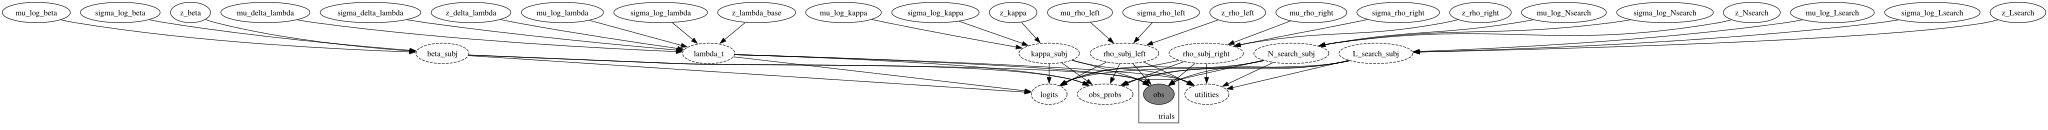

In [13]:

n_subj = int(np.max(inputs["subj_idx"])) + 1
n_cond = int(np.max(inputs["cond_idx"])) + 1
numpyro.render_model(colored_maze_utility_hierarchical, model_args=(    
    jnp.array(inputs["subj_idx"]),
    jnp.array(inputs["cond_idx"]),
    jnp.array(inputs["cache_valid"]),
    jnp.array(inputs["rim_path_length"]),
    jnp.array(inputs["EN_search"]),
    jnp.array(inputs["EN_search"]),
    jnp.array(inputs["obs_solution_slot"]),
    n_subj,
    n_cond,),
    filename=os.path.join(figpath,'exp1_model.png'))

# 5-fold CV model fits--and the full model fit

In [14]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import numpyro
from numpyro.infer import NUTS, MCMC


# ============================================================
# Metrics
# ============================================================

def categorical_log_loss(y, p, eps=1e-15):
    """
    Mean negative log probability assigned to the observed class.

    y: shape [T], integer labels 0..C-1
    p: shape [T, C], predicted probabilities
    """
    p = np.clip(np.asarray(p), eps, 1.0 - eps)
    y = np.asarray(y, dtype=int)
    return -np.mean(np.log(p[np.arange(len(y)), y]))


def multiclass_brier_score(y, p):
    """
    Multiclass Brier score: mean sum_c (p_c - 1[y=c])^2.
    """
    y = np.asarray(y, dtype=int)
    p = np.asarray(p)
    y_onehot = np.eye(p.shape[1])[y]
    return np.mean(np.sum((p - y_onehot) ** 2, axis=1))


def multiclass_accuracy(y, p):
    y = np.asarray(y, dtype=int)
    pred = np.argmax(p, axis=1)
    return np.mean(pred == y)


def binary_log_loss(y, p, eps=1e-15):
    p = np.clip(np.asarray(p), eps, 1.0 - eps)
    y = np.asarray(y, dtype=int)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def binary_brier_score(y, p):
    y = np.asarray(y, dtype=int)
    p = np.asarray(p)
    return np.mean((p - y) ** 2)


def binary_accuracy(y, p):
    y = np.asarray(y, dtype=int)
    return np.mean((p >= 0.5) == y)


# ============================================================
# Subject-grouped stratified folds
# ============================================================

def make_stratified_group_folds(y_binary, group, K=5, seed=0):
    """
    Python analogue of the R function make_stratified_folds().

    Holds out entire participants while greedily balancing the binary
    response rate across folds.

    Here y_binary will usually be:
        y_binary = (obs_solution_slot != 0).astype(int)
    """
    rng = np.random.default_rng(seed)

    y_binary = np.asarray(y_binary, dtype=int)
    group = np.asarray(group).astype(str)

    if not np.all(np.isin(y_binary, [0, 1])):
        raise ValueError("y_binary must contain only 0/1 values.")

    group_levels = pd.unique(group)

    if len(group_levels) < K:
        raise ValueError(
            f"Number of groups ({len(group_levels)}) is smaller than K ({K})."
        )

    rows = []
    for g in group_levels:
        idx = np.where(group == g)[0]
        n = len(idx)
        n_pos = int(y_binary[idx].sum())
        rows.append({
            "group": g,
            "n": n,
            "n_pos": n_pos,
            "prop_pos": n_pos / n,
        })

    group_summary = pd.DataFrame(rows)

    # Randomize ties, then sort high-to-low by response proportion.
    group_summary = group_summary.sample(
        frac=1.0,
        random_state=seed
    ).sort_values("prop_pos", ascending=False).reset_index(drop=True)

    folds_groups = [[] for _ in range(K)]
    fold_n = np.zeros(K, dtype=float)
    fold_pos = np.zeros(K, dtype=float)

    global_prop = y_binary.mean()

    for _, row in group_summary.iterrows():
        this_n = row["n"]
        this_pos = row["n_pos"]

        candidate_scores = []
        for k in range(K):
            new_n = fold_n[k] + this_n
            new_pos = fold_pos[k] + this_pos
            new_prop = new_pos / new_n

            score = abs(new_prop - global_prop) + 0.001 * new_n
            candidate_scores.append(score)

        k_best = int(np.argmin(candidate_scores))

        folds_groups[k_best].append(row["group"])
        fold_n[k_best] += this_n
        fold_pos[k_best] += this_pos

    folds = []
    for gs in folds_groups:
        test_idx = np.where(np.isin(group, gs))[0]
        folds.append(test_idx)

    return folds


# ============================================================
# Input construction and subject reindexing
# ============================================================

def build_inputs_from_df(df, rim_path_length, L_budget=70.0):
    """
    Builds the same input dictionary used originally.

    Assumes:
      - df["subj_idx"] contains subject IDs
      - df["cond"] is coded 0/1
      - df["cache_valid"] contains length-2 arrays/lists
      - df["obs_solution_slot"] is 0=search, 1=left, 2=right
    """
    df = df.sort_values(["subj_idx", "block", "trial"]).reset_index(drop=True)

    inputs = dict(
        subj_idx=np.asarray(df["subj_idx"], dtype=int),
        cond_idx=np.asarray(df["cond"], dtype=int),
        cache_valid=np.stack(df["cache_valid"].to_numpy()),
        rim_path_length=rim_path_length * np.ones((len(df), 2)),
        EU_search=(L_budget - df["search_path_len"].mean()) * np.ones((len(df),)),
        EN_search=df["search_cost"].mean() * np.ones((len(df),)),
        obs_solution_slot=np.asarray(df["obs_solution_slot"], dtype=int),
    )

    return inputs


def reindex_train_subjects(train_df, test_df, group_col="subj_idx"):
    """
    Reindex training subjects to 0..S_train-1.

    Test subjects are not reindexed into the training subject space because
    they are held out. For prediction, we will not use test subject-specific
    random effects anyway.
    """
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_subjects = pd.unique(train_df[group_col])
    subj_to_new = {old: new for new, old in enumerate(train_subjects)}

    train_df[group_col] = train_df[group_col].map(subj_to_new).astype(int)

    return train_df, test_df, subj_to_new


# ============================================================
# Population-level prediction for held-out subjects
# ============================================================

def predict_probs_population_only(
    posterior_samples,
    cond_idx,
    cache_valid,
    rim_path_length,
    L_budget=70.0,
):
    """
    Predict held-out participants using population-level parameters only.

    Works for both:
      - full model with condition-dependent lambda
      - null model without condition-dependent lambda

    Held-out subject-level z terms are set to zero, matching fixed-effects-only
    prediction in GLMMs.
    """
    cond_idx = jnp.asarray(cond_idx)
    cache_valid = jnp.asarray(cache_valid)
    rim_path_length = jnp.asarray(rim_path_length)

    # -----------------------------
    # Population-level subject parameters, z = 0
    # -----------------------------
    beta = jnp.exp(posterior_samples["mu_log_beta"])
    kappa = jnp.exp(posterior_samples["mu_log_kappa"])

    rho_left = posterior_samples["mu_rho_left"]
    rho_right = posterior_samples["mu_rho_right"]

    N_search = jnp.exp(posterior_samples["mu_log_Nsearch"])
    L_search = jnp.exp(posterior_samples["mu_log_Lsearch"])

    log_lambda_base = posterior_samples["mu_log_lambda"]

    # Full model has this; null model does not.
    if "mu_delta_lambda" in posterior_samples:
        delta_lambda = posterior_samples["mu_delta_lambda"]
    else:
        delta_lambda = jnp.zeros_like(log_lambda_base)

    # Broadcast to [D, T]
    beta_t = beta[:, None]
    kappa_t = kappa[:, None]
    rho_left_t = rho_left[:, None]
    rho_right_t = rho_right[:, None]
    N_search_t = N_search[:, None]
    L_search_t = L_search[:, None]

    cond_is_hard = (cond_idx == 1)[None, :]
    log_lambda_t = log_lambda_base[:, None] + delta_lambda[:, None] * cond_is_hard
    lambda_t = jnp.exp(log_lambda_t)

    cache_valid_left = cache_valid[None, :, 0]
    cache_valid_right = cache_valid[None, :, 1]

    rim_left_len = rim_path_length[None, :, 0]
    rim_right_len = rim_path_length[None, :, 1]

    # -----------------------------
    # Utilities
    # -----------------------------
    U_left_base = jnp.where(
        cache_valid_left == 1,
        L_budget - rim_left_len,
        -kappa_t,
    )

    U_right_base = jnp.where(
        cache_valid_right == 1,
        L_budget - rim_right_len,
        -kappa_t,
    )

    U_left = U_left_base + rho_left_t
    U_right = U_right_base + rho_right_t

    U_search = (L_budget - L_search_t) - lambda_t * N_search_t

    utilities = jnp.stack([U_search, U_left, U_right], axis=2)
    logits = beta_t[:, :, None] * utilities

    probs = jax.nn.softmax(logits, axis=2)
    p_mean = probs.mean(axis=0)

    return np.asarray(p_mean)


# ============================================================
# One model fit
# ============================================================

def fit_one_numpyro_model(
    model,
    inputs,
    n_subj,
    n_cond,
    seed=0,
    num_warmup=4000,
    num_samples=2000,
    num_chains=4,
    target_accept_prob=0.8,
):
    kernel = NUTS(model, target_accept_prob=target_accept_prob)

    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
    )

    mcmc.run(
        jax.random.PRNGKey(seed),
        subj_idx=jnp.array(inputs["subj_idx"]),
        cond_idx=jnp.array(inputs["cond_idx"]),
        cache_valid=jnp.array(inputs["cache_valid"]),
        rim_path_length=jnp.array(inputs["rim_path_length"]),
        EU_search=jnp.array(inputs["EU_search"]),
        EN_search=jnp.array(inputs["EN_search"]),
        obs_solution_slot=jnp.array(inputs["obs_solution_slot"]),
        n_subj=int(n_subj),
        n_cond=int(n_cond),
    )

    return mcmc


# ============================================================
# 5-fold subject-level CV wrapper
# ============================================================

def cv_numpyro_solution_model_by_subject(
    df,
    model,
    rim_path_length,
    group_col="subj_idx",
    K=5,
    seed=0,
    L_budget=70.0,
    num_warmup=4000,
    num_samples=2000,
    num_chains=4,
    target_accept_prob=0.8,
    fit_full=True,
):
    """
    5-fold grouped CV for the Numpyro solution-driven model.

    The held-out subjects are predicted using population-level parameters only,
    matching the between-participant prediction logic of my R GLME/LME CV code.

    Returns:
        dict with:
          - cv_table
          - cv_avg
          - fold_results
          - fit_full, optionally
          - cv_type
    """
    df = df.sort_values([group_col, "block", "trial"]).reset_index(drop=True).copy()

    # Binary stratification target: search vs reuse.
    y_reuse_binary = (df["obs_solution_slot"].to_numpy() != 0).astype(int)

    folds = make_stratified_group_folds(
        y_binary=y_reuse_binary,
        group=df[group_col].to_numpy(),
        K=K,
        seed=seed,
    )

    n_cond_full = int(df["cond"].max()) + 1

    rows = []
    fold_results = []

    for k, te_idx in enumerate(folds, start=1):
        tr_idx = np.setdiff1d(np.arange(len(df)), te_idx)

        train_df_raw = df.iloc[tr_idx].copy()
        test_df = df.iloc[te_idx].copy()

        # Reindex training subjects to 0..S_train-1.
        train_df, test_df, subj_to_new = reindex_train_subjects(
            train_df_raw,
            test_df,
            group_col=group_col,
        )

        train_inputs = build_inputs_from_df(
            train_df,
            rim_path_length=rim_path_length,
            L_budget=L_budget,
        )

        test_inputs = build_inputs_from_df(
            test_df,
            rim_path_length=rim_path_length,
            L_budget=L_budget,
        )

        n_train_subj = train_df[group_col].nunique()

        mcmc_k = fit_one_numpyro_model(
            model=model,
            inputs=train_inputs,
            n_subj=n_train_subj,
            n_cond=n_cond_full,
            seed=seed + k,
            num_warmup=num_warmup,
            num_samples=num_samples,
            num_chains=num_chains,
            target_accept_prob=target_accept_prob,
        )

        posterior_k = mcmc_k.get_samples()

        # Held-out participants: population-only prediction.
        p_test = predict_probs_population_only(
            posterior_samples=posterior_k,
            cond_idx=test_inputs["cond_idx"],
            cache_valid=test_inputs["cache_valid"],
            rim_path_length=test_inputs["rim_path_length"],
            L_budget=L_budget,
        )

        y_test = test_inputs["obs_solution_slot"]

        # Multiclass metrics: search / left reuse / right reuse.
        mean_logloss = categorical_log_loss(y_test, p_test)
        brier = multiclass_brier_score(y_test, p_test)
        acc = multiclass_accuracy(y_test, p_test)

        # Binary reuse metrics: search vs any reuse.
        y_reuse_test = (y_test != 0).astype(int)
        p_reuse_test = p_test[:, 1] + p_test[:, 2]

        reuse_logloss = binary_log_loss(y_reuse_test, p_reuse_test)
        reuse_brier = binary_brier_score(y_reuse_test, p_reuse_test)
        reuse_acc = binary_accuracy(y_reuse_test, p_reuse_test)

        row = dict(
            fold=k,
            n_train=len(train_df),
            n_test=len(test_df),
            n_train_subjects=train_df[group_col].nunique(),
            n_test_subjects=test_df[group_col].nunique(),
            n_with_RE=0,
            n_FE_only=len(test_df),

            # Three-choice model metrics.
            mean_logloss=mean_logloss,
            brier=brier,
            acc=acc,

            # Search-vs-reuse metrics.
            reuse_logloss=reuse_logloss,
            reuse_brier=reuse_brier,
            reuse_acc=reuse_acc,
        )

        rows.append(row)

        fold_results.append(dict(
            fold=k,
            mcmc=mcmc_k,
            posterior_samples=posterior_k,
            test_index=te_idx,
            train_index=tr_idx,
            p_test=p_test,
            y_test=y_test,
            test_df=test_df,
        ))

    cv_table = pd.DataFrame(rows)

    cv_avg = cv_table[
        [
            "mean_logloss",
            "brier",
            "acc",
            "reuse_logloss",
            "reuse_brier",
            "reuse_acc",
        ]
    ].mean()

    out = dict(
        cv_table=cv_table,
        cv_avg=cv_avg,
        fold_results=fold_results, # Too large to save?
        cv_type="between-participant grouped 5-fold CV; held-out predictions use population-level parameters only",
    )

    if fit_full:
        full_inputs = build_inputs_from_df(
            df,
            rim_path_length=rim_path_length,
            L_budget=L_budget,
        )

        n_subj_full = int(df[group_col].nunique())

        # Important: full-data subject IDs should also be contiguous.
        # If df["subj_idx"] is already 0..S-1, this is redundant but safe.
        df_full = df.copy()
        subj_levels = pd.unique(df_full[group_col])
        subj_to_new = {old: new for new, old in enumerate(subj_levels)}
        df_full[group_col] = df_full[group_col].map(subj_to_new).astype(int)

        full_inputs = build_inputs_from_df(
            df_full,
            rim_path_length=rim_path_length,
            L_budget=L_budget,
        )

        mcmc_full = fit_one_numpyro_model(
            model=model,
            inputs=full_inputs,
            n_subj=n_subj_full,
            n_cond=n_cond_full,
            seed=seed,
            num_warmup=num_warmup,
            num_samples=num_samples,
            num_chains=num_chains,
            target_accept_prob=target_accept_prob,
        )

        out["fit_full"] = mcmc_full
        out["posterior_full"] = mcmc_full.get_samples()

    return out

In [84]:
cv_res = cv_numpyro_solution_model_by_subject(
    df=df_human_modeling,
    model=colored_maze_utility_hierarchical_null,
    rim_path_length=rim_path_length,
    group_col="subj_idx",
    K=5,
    seed=0,
    L_budget=70.0,
    num_warmup=4000,
    num_samples=2000,
    num_chains=4,
    target_accept_prob=0.8,
    fit_full=True,
)

print(cv_res["cv_avg"])

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

...

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

mean_logloss     0.923295
brier            0.546893
acc              0.619613
reuse_logloss    0.711954
reuse_brier      0.251745
reuse_acc        0.619613
dtype: float64


In [85]:
with open(os.path.join(fitspath,'exp1_sol_driven_model_hierarchical_null_5foldcv.pickle'), 'wb') as handle:
    pickle.dump(cv_res, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 5-fold CV model comparison

In [15]:
# Compare 5-fold CV test loss. 

with open(os.path.join(fitspath,'exp1_sol_driven_model_hierarchical_5foldcv.pickle'), 'rb') as handle:
    cv_target = pickle.load(handle)
print("\n----- Target model -------")
print(cv_target["cv_avg"])

with open(os.path.join(fitspath,'exp1_sol_driven_model_hierarchical_null_5foldcv.pickle'), 'rb') as handle:
    cv_null = pickle.load(handle)
print("\n----- Null model -------")
print(cv_null["cv_avg"])


----- Target model -------
mean_logloss     0.904193
brier            0.506085
acc              0.619613
reuse_logloss    0.673831
reuse_brier      0.223944
reuse_acc        0.652356
dtype: float64

----- Null model -------
mean_logloss     0.923295
brier            0.546893
acc              0.619613
reuse_logloss    0.711954
reuse_brier      0.251745
reuse_acc        0.619613
dtype: float64


In [16]:
import os
import pickle
import numpy as np
import arviz as az
import jax.numpy as jnp
from numpyro.infer import log_likelihood


def get_full_fit_samples_and_inputs(cv_res):
    """
    Extract posterior samples and model inputs from the new CV result objects.

    Expected from the newer CV code:
        cv_res["posterior_full"]
        cv_res["full_inputs"]

    Fallback:
        cv_res["fit_full"].get_samples()
    """
    if "posterior_full" in cv_res:
        posterior_samples = cv_res["posterior_full"]
    elif "fit_full" in cv_res:
        posterior_samples = cv_res["fit_full"].get_samples()
    else:
        raise KeyError(
            "Could not find posterior samples. Expected 'posterior_full' or 'fit_full'."
        )

    return posterior_samples


def compute_loo_for_colored_maze_model_from_cvres(
    cv_res,
    model_fn,
    L_budget=70.0,
    inputs=inputs
):
    """
    Compute PSIS-LOO / ELPD-LOO for an Experiment 1 NumPyro model
    using the full-data fit stored inside the newer 5-fold-CV result object.

    Parameters
    ----------
    cv_res : dict
        New CV result object containing posterior_full and full_inputs.
    model_fn : callable
        NumPyro model function.
    L_budget : float
        Experiment 1 uses L_budget=70.0.

    Returns
    -------
    loo_res : arviz.ELPDData
    idata : arviz.InferenceData
    """
    posterior_samples = get_full_fit_samples_and_inputs(cv_res)

    # Keep samples as (draws, ...)
    posterior_samples_unchained = {
        k: np.asarray(v)
        for k, v in posterior_samples.items()
    }

    n_subj = int(np.max(inputs["subj_idx"])) + 1
    n_cond = int(np.max(inputs["cond_idx"])) + 1

    log_lik = log_likelihood(
        model_fn,
        posterior_samples_unchained,
        subj_idx=jnp.array(inputs["subj_idx"]),
        cond_idx=jnp.array(inputs["cond_idx"]),
        cache_valid=jnp.array(inputs["cache_valid"]),
        rim_path_length=jnp.array(inputs["rim_path_length"]),
        EU_search=jnp.array(inputs["EU_search"]),
        EN_search=jnp.array(inputs["EN_search"]),
        obs_solution_slot=jnp.array(inputs["obs_solution_slot"]),
        n_subj=n_subj,
        n_cond=n_cond,
        L_budget=L_budget,
    )

    # Add singleton chain dimension for ArviZ:
    # posterior:       (draws, ...) -> (1, draws, ...)
    # log_likelihood:  (draws, T)   -> (1, draws, T)
    posterior_samples_chained = {
        k: np.expand_dims(v, axis=0)
        for k, v in posterior_samples_unchained.items()
    }

    log_lik_chained = {
        "obs": np.expand_dims(np.asarray(log_lik["obs"]), axis=0)
    }

    idata = az.from_dict(
        posterior=posterior_samples_chained,
        log_likelihood=log_lik_chained,
    )

    loo_res = az.loo(
        idata,
        var_name="obs",
        pointwise=True,
    )

    return loo_res, idata


# ============================================================
# Compute PSIS-LOO
# ============================================================

loo_target, idata_target = compute_loo_for_colored_maze_model_from_cvres(
    cv_target,
    colored_maze_utility_hierarchical,
    L_budget=70.0,
)

loo_null, idata_null = compute_loo_for_colored_maze_model_from_cvres(
    cv_null,
    colored_maze_utility_hierarchical_null,
    L_budget=70.0,
)

cmp_simple = az.compare(
    {
        "target_condition_specific_lambda": idata_target,
        "null_shared_lambda": idata_null,
    },
    ic="loo",
)

print(cmp_simple)

print("\n----- Target model LOO -----")
print(loo_target)

print("\n----- Null model LOO -----")
print(loo_null)


/Users/liu_s/pyro_env2/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/liu_s/pyro_env2/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/liu_s/pyro_env2/lib/python3.11/site-packages/arviz/stat

                                  rank     elpd_loo       p_loo   elpd_diff  \
target_condition_specific_lambda     0  -983.070426  149.463496    0.000000   
null_shared_lambda                   1 -1456.831179  113.597648  473.760753   

                                    weight         se        dse  warning  \
target_condition_specific_lambda  0.992689  34.670837   0.000000     True   
null_shared_lambda                0.007311  30.204035  23.871024     True   

                                 scale  
target_condition_specific_lambda   log  
null_shared_lambda                 log  

----- Target model LOO -----
Computed from 8000 posterior samples and 2054 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -983.07    34.67
p_loo      149.46        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2041   99.4%
   (0.70, 1]   (bad)    

/Users/liu_s/pyro_env2/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


# Posterior predictive samples visualization

Note: these figures correspond to the participant-level 5-fold cross validation results. For each participant, we use the fitted model in which they belonged to the held-out fold (i.e., the model was deliberatedly NOT fit to this participant's data), and sample participant-level parameters from the fitted population-level prior distribution. We then used these parameters to generate the participant's data on each trial. 

The above procedure is thus a test of model generalization/predictions on held-out participants.

In [17]:
import gc
import numpy as np
import pandas as pd
from numpyro.infer import Predictive
import jax
import jax.numpy as jnp

In [18]:
def _get_fold_results(cv_res):
    if "fold_results" not in cv_res:
        raise KeyError(
            "cv_res does not contain 'fold_results'. "
            "Need fold-specific results for held-out CV PPC plots."
        )
    return cv_res["fold_results"]


def _get_fold_test_df(fr):
    for key in ["test_df", "df_test", "test_data"]:
        if key in fr:
            return fr[key].copy()
    raise KeyError(
        "Could not find held-out test dataframe in fold result. "
        "Expected one of: 'test_df', 'df_test', 'test_data'."
    )


def _get_fold_p_test(fr):
    for key in ["p_test", "probs_test", "pred_probs_test"]:
        if key in fr:
            return np.asarray(fr[key])
    raise KeyError(
        "Could not find held-out predicted probabilities in fold result. "
        "Expected one of: 'p_test', 'probs_test', 'pred_probs_test'."
    )


def _coerce_probs_to_mean(probs):
    """
    Accept either:
        [T, 3]          posterior mean probabilities
        [draws, T, 3]   posterior draw-level probabilities

    Returns:
        [T, 3]
    """
    probs = np.asarray(probs)

    if probs.ndim == 2:
        return probs

    if probs.ndim == 3:
        return probs.mean(axis=0)

    raise ValueError(
        f"Expected p_test shape [T, 3] or [draws, T, 3], got {probs.shape}."
    )


def _sample_choices_from_probs(probs, rng):
    """
    Sample one categorical posterior-predictive choice per trial.

    Exp 1 action coding:
        0 = search
        1 = left rim
        2 = right rim
    """
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum(axis=1, keepdims=True)

    return np.array([
        rng.choice(probs.shape[1], p=probs[t])
        for t in range(probs.shape[0])
    ])

In [19]:
def _drop_subject_level_sites_exp1(posterior_samples):
    """
    Keep population-level posterior samples, but drop subject-level latent sites
    so NumPyro will sample new held-out-subject random effects.

    This is deliberately conservative: it drops common subject-level z-sites and
    deterministic probability sites.
    """
    drop_prefixes = (
        "z_",                 # common non-centered subject-level latent names
        "subj_",              # possible subject-level deterministic names
        "log_beta_subj",
        "log_lambda_subj",
        "delta_lambda_subj",
    )

    drop_exact = {
        "obs_probs",
        "logits",
        "probs",
    }

    out = {}

    for k, v in posterior_samples.items():
        if k in drop_exact:
            continue

        if any(k.startswith(prefix) for prefix in drop_prefixes):
            continue

        out[k] = np.asarray(v)

    return out


def _reindex_heldout_subjects(test_df, subj_col="subj_idx"):
    """
    Reindex held-out subjects to 0..S_test-1 so that the model can sample
    new subject-level effects for exactly the held-out participants.
    """
    test_df = test_df.copy()

    if subj_col not in test_df.columns:
        if "Subj" in test_df.columns:
            subj_col = "Subj"
        else:
            raise KeyError(
                "Could not find subject column. Expected 'subj_idx' or 'Subj'."
            )

    unique_subjs = pd.unique(test_df[subj_col])
    subj_map = {s: i for i, s in enumerate(unique_subjs)}

    subj_idx_new = test_df[subj_col].map(subj_map).to_numpy(dtype=int)

    return subj_idx_new, subj_map


def _get_fold_posterior_samples(fr):
    for key in ["posterior_samples", "samples", "posterior"]:
        if key in fr:
            return fr[key]

    if "mcmc" in fr:
        return fr["mcmc"].get_samples()

    if "fit" in fr:
        return fr["fit"].get_samples()

    raise KeyError(
        "Could not find fold-specific posterior samples. "
        "Need fr['posterior_samples'] or fr['mcmc']/fr['fit'] to sample "
        "new held-out participant random effects."
    )

In [20]:
def _build_exp1_test_inputs_from_test_df(
    test_df,
    L_budget=70.0,
    rim_path_length=None,
    EU_search=None,
    EN_search=None,
):
    """
    Build Experiment 1 model inputs for a held-out test dataframe.

    Prefer using fr["test_inputs"] if your CV code saved it. This fallback
    reconstructs inputs from test_df.

    Required in test_df:
        subj_idx or Subj
        cond or cond_idx
        cache_valid
        obs_solution_slot, if available only for checking; not used for prediction

    rim_path_length / EU_search / EN_search:
        If these are columns in test_df, they are used.
        Otherwise pass them explicitly.
    """
    test_df = test_df.reset_index(drop=True).copy()

    subj_idx_new, subj_map = _reindex_heldout_subjects(test_df)

    if "cond_idx" in test_df.columns:
        cond_idx = test_df["cond_idx"].to_numpy(dtype=int)
    elif "cond" in test_df.columns:
        cond_idx = test_df["cond"].to_numpy(dtype=int)
    else:
        raise KeyError("test_df needs 'cond_idx' or 'cond'.")

    if "cache_valid" not in test_df.columns:
        raise KeyError("test_df needs 'cache_valid'.")

    cache_valid = np.stack(test_df["cache_valid"].to_numpy())

    T = len(test_df)

    # --------------------------------------------------------
    # rim_path_length: coerce to shape [T, 2]
    # --------------------------------------------------------
    if "rim_path_length" in test_df.columns:
        rpl_raw = test_df["rim_path_length"].to_numpy()

        # Handles a column where each row already contains a length-2 object.
        try:
            rpl = np.stack(rpl_raw).astype(float)
        except Exception:
            # Handles a scalar-valued column.
            rpl = np.asarray(rpl_raw, dtype=float)

    else:
        if rim_path_length is None:
            raise ValueError(
                "rim_path_length not found in test_df. "
                "Pass rim_path_length explicitly, e.g. rim_path_length=rim_path_length."
            )

        rpl = np.asarray(rim_path_length, dtype=float)

    # Now normalize all acceptable cases to [T, 2].
    if rpl.ndim == 0:
        # scalar -> same length for left/right on all trials
        rpl = float(rpl) * np.ones((T, 2))

    elif rpl.ndim == 1:
        if rpl.shape[0] == 2:
            # [left_len, right_len] -> repeat over trials
            rpl = np.tile(rpl[None, :], (T, 1))

        elif rpl.shape[0] == T:
            # trial-specific scalar length -> duplicate into left/right columns
            rpl = np.column_stack([rpl, rpl])

        else:
            raise ValueError(
                f"rim_path_length is 1D with shape {rpl.shape}; "
                f"expected scalar, shape [2], shape [T], or shape [T, 2]."
            )

    elif rpl.ndim == 2:
        if rpl.shape == (T, 2):
            pass

        elif rpl.shape == (1, 2):
            rpl = np.tile(rpl, (T, 1))

        elif rpl.shape == (T, 1):
            rpl = np.repeat(rpl, 2, axis=1)

        else:
            raise ValueError(
                f"rim_path_length has shape {rpl.shape}; "
                f"expected [T, 2], [1, 2], [T, 1], scalar, [2], or [T]."
            )

    else:
        raise ValueError(
            f"rim_path_length has unsupported shape {rpl.shape}."
        )

    if rpl.shape != (T, 2):
        raise ValueError(
            f"After coercion, rim_path_length has shape {rpl.shape}; "
            f"expected {(T, 2)}."
        )

    # --------------------------------------------------------
    # EU_search
    # --------------------------------------------------------
    if "EU_search" in test_df.columns:
        eu = test_df["EU_search"].to_numpy(dtype=float)
    else:
        if EU_search is None:
            raise ValueError(
                "EU_search not found in test_df. Pass EU_search explicitly."
            )
        eu = np.asarray(EU_search, dtype=float)
        if eu.ndim == 0:
            eu = np.repeat(float(eu), T)
        elif eu.ndim == 1 and eu.shape[0] == T:
            pass
        else:
            raise ValueError(
                f"EU_search has unexpected shape {eu.shape}; expected scalar or [T]."
            )

    # --------------------------------------------------------
    # EN_search
    # --------------------------------------------------------
    if "EN_search" in test_df.columns:
        en = test_df["EN_search"].to_numpy(dtype=float)
    else:
        if EN_search is None:
            raise ValueError(
                "EN_search not found in test_df. Pass EN_search explicitly."
            )
        en = np.asarray(EN_search, dtype=float)
        if en.ndim == 0:
            en = np.repeat(float(en), T)
        elif en.ndim == 1 and en.shape[0] == T:
            pass
        else:
            raise ValueError(
                f"EN_search has unexpected shape {en.shape}; expected scalar or [T]."
            )

    inputs = dict(
        subj_idx=subj_idx_new,
        cond_idx=cond_idx,
        cache_valid=cache_valid,
        rim_path_length=rpl,
        EU_search=eu,
        EN_search=en,
        obs_solution_slot=None,
        n_subj=len(subj_map),
        n_cond=int(np.max(cond_idx)) + 1,
        L_budget=L_budget,
    )

    return inputs

In [21]:
def predict_exp1_heldout_probs_sampled_re(
    fr,
    model_fn,
    rng_key,
    L_budget=70.0,
    rim_path_length=None,
    EU_search=None,
    EN_search=None,
    max_draws=None,
):
    """
    Compute held-out predictive probabilities after sampling new held-out
    participant-level parameters from the fitted population-level distributions.

    This does NOT match the 5-fold CV NLL procedure if that procedure used
    population-level/fixed-effect predictions only. This is for visualization.

    Requires fold-specific posterior samples.
    """
    test_df = _get_fold_test_df(fr).reset_index(drop=True)

    posterior_samples = _get_fold_posterior_samples(fr)

    if max_draws is not None:
        posterior_samples = {
            k: np.asarray(v)[:max_draws]
            for k, v in posterior_samples.items()
        }

    posterior_population = _drop_subject_level_sites_exp1(posterior_samples)

    if "test_inputs" in fr:
        inputs = fr["test_inputs"].copy()

        # Reindex subjects to held-out new-subject indices.
        subj_idx_new, subj_map = _reindex_heldout_subjects(test_df)
        inputs["subj_idx"] = subj_idx_new
        inputs["n_subj"] = len(subj_map)
        inputs["obs_solution_slot"] = None

        if "cond_idx" not in inputs and "cond" in inputs:
            inputs["cond_idx"] = inputs["cond"]

        if "n_cond" not in inputs:
            inputs["n_cond"] = int(np.max(inputs["cond_idx"])) + 1

        if "L_budget" not in inputs:
            inputs["L_budget"] = L_budget

    else:
        inputs = _build_exp1_test_inputs_from_test_df(
            test_df=test_df,
            L_budget=L_budget,
            rim_path_length=rim_path_length,
            EU_search=EU_search,
            EN_search=EN_search,
        )

    predictive = Predictive(
        model_fn,
        posterior_samples=posterior_population,
        return_sites=["obs_probs"],
    )

    out = predictive(
        rng_key,
        subj_idx=jnp.array(inputs["subj_idx"]),
        cond_idx=jnp.array(inputs["cond_idx"]),
        cache_valid=jnp.array(inputs["cache_valid"]),
        rim_path_length=jnp.array(inputs["rim_path_length"]),
        EU_search=jnp.array(inputs["EU_search"]),
        EN_search=jnp.array(inputs["EN_search"]),
        obs_solution_slot=None,
        n_subj=int(inputs["n_subj"]),
        n_cond=int(inputs["n_cond"]),
        L_budget=L_budget,
    )

    probs_draws = np.asarray(out["obs_probs"])  # [draws, T, 3]
    probs_mean = probs_draws.mean(axis=0)       # [T, 3]

    del posterior_samples
    del posterior_population
    del predictive
    del out
    gc.collect()

    return probs_mean

In [24]:
def summarize_model_p_rim_heldout(df_pred):
    """
    Model analogue of:
        P(submitted path on rim)

    For pred_mode == "probs":
        mean held-out posterior predictive probability.

    For pred_mode == "choices":
        mean sampled rim choice indicator.
    """
    group_cols = ["model", "Subj", "cond"]

    if "sim" in df_pred.columns:
        group_cols = ["model", "sim", "Subj", "cond"]

    out = (
        df_pred
        .groupby(group_cols, as_index=False)
        .agg(model_p_rim=("p_rim", "mean"))
    )

    return out


def summarize_model_correct_rim_given_reuse_heldout(df_pred, eps=1e-12):
    """
    Model analogue of:
        P(submit correct rim path | one rim path is blocked)

    For pred_mode == "probs":
        P(correct rim | rim) = P(correct rim) / P(left or right rim)

    For pred_mode == "choices":
        Filter to sampled rim choices, then compute whether the sampled
        rim choice was the open/correct rim.
    """
    pred_mode_vals = df_pred["pred_mode"].dropna().unique().tolist()

    if len(pred_mode_vals) != 1:
        raise ValueError(
            "Expected one pred_mode per dataframe. "
            f"Found: {pred_mode_vals}"
        )

    pred_mode = pred_mode_vals[0]

    df_temp = df_pred.copy()
    df_temp = df_temp[
        df_temp["left_rim_path_open"] != df_temp["right_rim_path_open"]
    ].copy()

    group_cols = ["model", "Subj", "cond"]

    if "sim" in df_temp.columns:
        group_cols = ["model", "sim", "Subj", "cond"]

    if pred_mode == "probs":
        df_temp["p_correct_rim_raw"] = np.where(
            df_temp["right_rim_path_open"] == 1,
            df_temp["p_right"],
            df_temp["p_left"],
        )

        df_temp["model_p_correct_given_rim"] = (
            df_temp["p_correct_rim_raw"] / np.clip(df_temp["p_rim"], eps, None)
        )

        out = (
            df_temp
            .groupby(group_cols, as_index=False)
            .agg(model_p_correct_given_rim=("model_p_correct_given_rim", "mean"))
        )

    elif pred_mode == "choices":
        df_temp = df_temp[df_temp["y_pred"].isin([1, 2])].copy()

        # action coding:
        #   1 = left rim
        #   2 = right rim
        df_temp["model_correct_rim_choice"] = np.where(
            df_temp["right_rim_path_open"] == 1,
            df_temp["y_pred"] == 2,
            df_temp["y_pred"] == 1,
        ).astype(float)

        out = (
            df_temp
            .groupby(group_cols, as_index=False)
            .agg(model_p_correct_given_rim=("model_correct_rim_choice", "mean"))
        )

    else:
        raise ValueError("pred_mode must be 'probs' or 'choices'.")

    return out

def make_heldout_prediction_df_exp1(
    cv_res,
    model_name,
    pred_mode="probs",
    participant_mode="population",
    model_fn=None,
    n_sim=1,
    seed=0,
    L_budget=70.0,
    rim_path_length=None,
    EU_search=None,
    EN_search=None,
    max_draws=None,
):
    """
    Create trial-level held-out prediction dataframe for Experiment 1.

    pred_mode:
        "probs"
            Visualize predictive probabilities.

        "choices"
            Sample a model-predicted dataset from predictive probabilities.

    participant_mode:
        "population"
            Use saved fr["p_test"]. This matches grouped 5-fold CV when p_test
            was computed using population-level/fixed-effect predictions only.

        "sampled_re"
            Recompute predictions by sampling new held-out participant-level
            random effects from the fold-specific posterior population-level
            distributions. This is a visualization-only PPC and does not match
            the fixed-effect-only CV loss.

    model_fn:
        Required when participant_mode == "sampled_re".
    """
    assert pred_mode in ["probs", "choices"]
    assert participant_mode in ["population", "sampled_re"]

    if participant_mode == "sampled_re" and model_fn is None:
        raise ValueError(
            "model_fn is required when participant_mode='sampled_re'."
        )

    rng = np.random.default_rng(seed)
    base_key = jax.random.PRNGKey(seed)

    fold_results = _get_fold_results(cv_res)

    all_rows = []

    for fold_idx, fr in enumerate(fold_results):
        test_df = _get_fold_test_df(fr).reset_index(drop=True)

        if participant_mode == "population":
            probs = _coerce_probs_to_mean(_get_fold_p_test(fr))

        elif participant_mode == "sampled_re":
            rng_key = jax.random.fold_in(base_key, fold_idx)

            probs = predict_exp1_heldout_probs_sampled_re(
                fr=fr,
                model_fn=model_fn,
                rng_key=rng_key,
                L_budget=L_budget,
                rim_path_length=rim_path_length,
                EU_search=EU_search,
                EN_search=EN_search,
                max_draws=max_draws,
            )

        if probs.shape[0] != len(test_df):
            raise ValueError(
                f"Fold {fold_idx}: probabilities have {probs.shape[0]} rows, "
                f"but test_df has {len(test_df)} rows."
            )

        if probs.shape[1] != 3:
            raise ValueError(
                f"Fold {fold_idx}: expected 3 choice probabilities "
                f"[search, left, right], got shape {probs.shape}."
            )

        if pred_mode == "probs":
            d = test_df.copy()
            d["model"] = model_name
            d["fold"] = fold_idx
            d["pred_mode"] = "probs"
            d["participant_mode"] = participant_mode

            d["p_search"] = probs[:, 0]
            d["p_left"] = probs[:, 1]
            d["p_right"] = probs[:, 2]
            d["p_rim"] = d["p_left"] + d["p_right"]

            all_rows.append(d)

        elif pred_mode == "choices":
            for sim in range(n_sim):
                y_pred = _sample_choices_from_probs(probs, rng)

                d = test_df.copy()
                d["model"] = model_name
                d["fold"] = fold_idx
                d["sim"] = sim
                d["pred_mode"] = "choices"
                d["participant_mode"] = participant_mode
                d["y_pred"] = y_pred

                d["p_search"] = (y_pred == 0).astype(float)
                d["p_left"] = (y_pred == 1).astype(float)
                d["p_right"] = (y_pred == 2).astype(float)
                d["p_rim"] = ((y_pred == 1) | (y_pred == 2)).astype(float)

                all_rows.append(d)

    df_pred = pd.concat(all_rows, ignore_index=True)

    required_cols = [
        "Subj", "cond",
        "left_rim_path_open", "right_rim_path_open",
        "p_search", "p_left", "p_right", "p_rim",
    ]

    missing = [c for c in required_cols if c not in df_pred.columns]
    if missing:
        raise KeyError(f"Held-out prediction dataframe is missing columns: {missing}")

    return df_pred

In [25]:
#PRED_MODE = "probs"
PRED_MODE = "choices"

#PARTICIPANT_MODE = "population"
PARTICIPANT_MODE = "sampled_re"


df_pred_target_cv = make_heldout_prediction_df_exp1(
    cv_res=cv_target,
    model_name="Target",
    pred_mode=PRED_MODE,
    participant_mode=PARTICIPANT_MODE,
    model_fn=colored_maze_utility_hierarchical,
    n_sim=1,
    seed=0,
    L_budget=70.0,
    rim_path_length=rim_path_length,
    EU_search=df_human_modeling["search_path_len"].pipe(lambda x: 70.0 - x.mean()),
    EN_search=df_human_modeling["search_cost"].mean(),
    max_draws=None,   # set e.g. 500 if memory/speed is an issue
)

df_pred_null_cv = make_heldout_prediction_df_exp1(
    cv_res=cv_null,
    model_name="Null",
    pred_mode=PRED_MODE,
    participant_mode=PARTICIPANT_MODE,
    model_fn=colored_maze_utility_hierarchical_null,
    n_sim=1,
    seed=1000,
    L_budget=70.0,
    rim_path_length=rim_path_length,
    EU_search=df_human_modeling["search_path_len"].pipe(lambda x: 70.0 - x.mean()),
    EN_search=df_human_modeling["search_cost"].mean(),
    max_draws=None,
)

df_pred_models_cv = pd.concat(
    [df_pred_target_cv, df_pred_null_cv],
    ignore_index=True,
)

df_model_p_rim_cv = summarize_model_p_rim_heldout(df_pred_models_cv)
df_model_correct_rim_cv = summarize_model_correct_rim_given_reuse_heldout(
    df_pred_models_cv
)

In [27]:
# Human panel 1:
# P(submitted path on rim)
df_human_p_rim = (
    df_allsubjs_test
    .groupby(["Subj", "cond"], as_index=False)
    .agg(human_p_rim=("path_on_rim", "mean"))
)


# Human panel 2:
# P(submit correct rim path | one rim path is blocked)
df_temp = df_allsubjs_test.copy()

df_temp = df_temp[df_temp["path_on_rim"] == 1]
df_temp = df_temp[df_temp["left_rim_path_open"] != df_temp["right_rim_path_open"]]
df_temp = df_temp[~np.isnan(df_temp["path_taken_on_leftorrightrim"])]

df_temp["sensitive_to_whichrimopen"] = (
    df_temp["right_rim_path_open"] == df_temp["path_taken_on_leftorrightrim"]
).astype(int)

df_human_correct_rim = (
    df_temp
    .groupby(["Subj", "cond"], as_index=False)
    .agg(human_p_correct_given_rim=("sensitive_to_whichrimopen", "mean"))
)

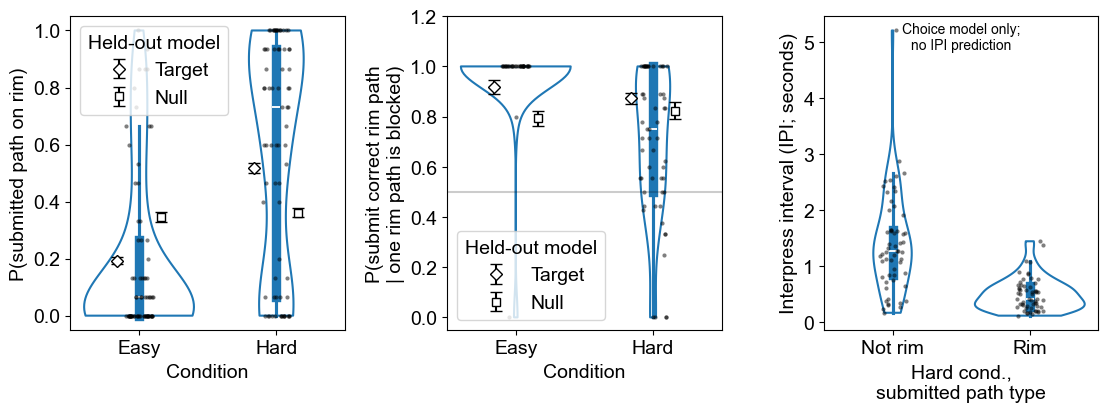

In [28]:
def mean_sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan
    if len(x) == 1:
        return np.mean(x), 0.0
    return np.mean(x), np.std(x, ddof=1) / np.sqrt(len(x))


def overlay_model_errorbars(
    ax,
    df_model,
    y,
    cond_order=[0, 1],
    model_order=("Target", "Null"),
    dodge=0.16,
    markers=None,
    capsize=4,
):
    if markers is None:
        markers = {"Target": "D", "Null": "s"}

    offsets = {
        model_order[0]: -dodge,
        model_order[1]: dodge,
    }

    for model_name in model_order:
        d_model = df_model[df_model["model"] == model_name].copy()

        xs = []
        means = []
        sems = []

        for cond in cond_order:
            vals = d_model.loc[d_model["cond"] == cond, y].dropna().values
            m, se = mean_sem(vals)

            xs.append(cond + offsets[model_name])
            means.append(m)
            sems.append(se)

        ax.errorbar(
            xs,
            means,
            yerr=sems,
            fmt=markers[model_name],
            linestyle="",
            capsize=capsize,
            color="k",
            markerfacecolor="white",
            markeredgecolor="k",
            label=model_name,
        )


plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["font.size"] = 14

cut = 0
inner = "box"

fig, ax = plt.subplots(1, 3, figsize=(13/1.15, 13/2.6/1.15))

cond_order = [0, 1]


# ============================================================
# Panel 1: P(path on rim)
# ============================================================

sns.violinplot(
    data=df_human_p_rim,
    x="cond",
    y="human_p_rim",
    order=cond_order,
    cut=cut,
    inner=inner,
    fill=False,
    ax=ax[0],
)

sns.stripplot(
    data=df_human_p_rim,
    x="cond",
    y="human_p_rim",
    order=cond_order,
    color="k",
    alpha=0.5,
    size=3,
    legend=False,
    ax=ax[0],
)

overlay_model_errorbars(
    ax=ax[0],
    df_model=df_model_p_rim_cv,
    y="model_p_rim",
    cond_order=cond_order,
)

ax[0].set_xlim([-0.5, 1.5])
ax[0].set_ylabel("P(submitted path on rim)")
ax[0].set_xlabel("Condition")
ax[0].set_xticks(np.arange(len(cond_order)))
ax[0].set_xticklabels(["Easy", "Hard"])
ax[0].legend(title="Held-out model", frameon=True)


# ============================================================
# Panel 2: P(correct rim | rim chosen, one rim blocked)
# ============================================================

sns.violinplot(
    data=df_human_correct_rim,
    x="cond",
    y="human_p_correct_given_rim",
    order=cond_order,
    cut=cut,
    inner=inner,
    fill=False,
    ax=ax[1],
)

sns.stripplot(
    data=df_human_correct_rim,
    x="cond",
    y="human_p_correct_given_rim",
    order=cond_order,
    color="k",
    alpha=0.5,
    size=3,
    legend=False,
    ax=ax[1],
)

overlay_model_errorbars(
    ax=ax[1],
    df_model=df_model_correct_rim_cv,
    y="model_p_correct_given_rim",
    cond_order=cond_order,
)

ax[1].plot([-1, 2], [0.5, 0.5], "k-", alpha=0.2)
ax[1].set_xlim([-0.5, 1.5])
ax[1].set_ylim([None, 1.2])
ax[1].set_ylabel("P(submit correct rim path\n| one rim path is blocked)")
ax[1].set_xlabel("Condition")
ax[1].set_xticks(np.arange(len(cond_order)))
ax[1].set_xticklabels(["Easy", "Hard"])
ax[1].legend(title="Held-out model", frameon=True)


# ============================================================
# Panel 3: Human IPI only
# ============================================================

df_allsubjs_test_avg_bycond = (
    df_allsubjs_test
    .groupby(["Subj", "cond", "path_on_rim"], as_index=False)
    [["first_cond", "rt", "first_rt", "submitted_path_rt",
      "submitted_path_presses", "submitted_path_avgrt"]]
    .mean()
)

df_ipi = df_allsubjs_test_avg_bycond[
    df_allsubjs_test_avg_bycond["cond"] == 1
].copy()

sns.violinplot(
    data=df_ipi,
    x="path_on_rim",
    y="submitted_path_avgrt",
    cut=cut,
    inner=inner,
    fill=False,
    ax=ax[2],
)

sns.stripplot(
    data=df_ipi,
    x="path_on_rim",
    y="submitted_path_avgrt",
    color="k",
    alpha=0.5,
    size=3,
    legend=False,
    ax=ax[2],
)

ax[2].set_xlim([-0.5, 1.5])
ax[2].set_ylabel("Interpress interval (IPI; seconds)")
ax[2].set_xlabel("Hard cond.,\nsubmitted path type")
ax[2].set_xticks([0, 1])
ax[2].set_xticklabels(["Not rim", "Rim"])

ax[2].text(
    0.5,
    0.98,
    "Choice model only;\nno IPI prediction",
    ha="center",
    va="top",
    transform=ax[2].transAxes,
    fontsize=10,
)

fig.tight_layout()

# plt.savefig(
#     os.path.join(figpath, f"exp1_heldout_cv_ppc_choice_results_{PRED_MODE}_{PARTICIPANT_MODE}.pdf"),
#     bbox_inches="tight"
# )

plt.show()

 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 -7.295 0.000    -0.860
 comparison  n  df       t     p  cohen_dz
cond 0 vs 1 72  71 -15.386 0.000    -1.813
 comparison  n  df      t     p  cohen_dz
cond 0 vs 1 72  71 -0.629 0.531    -0.074


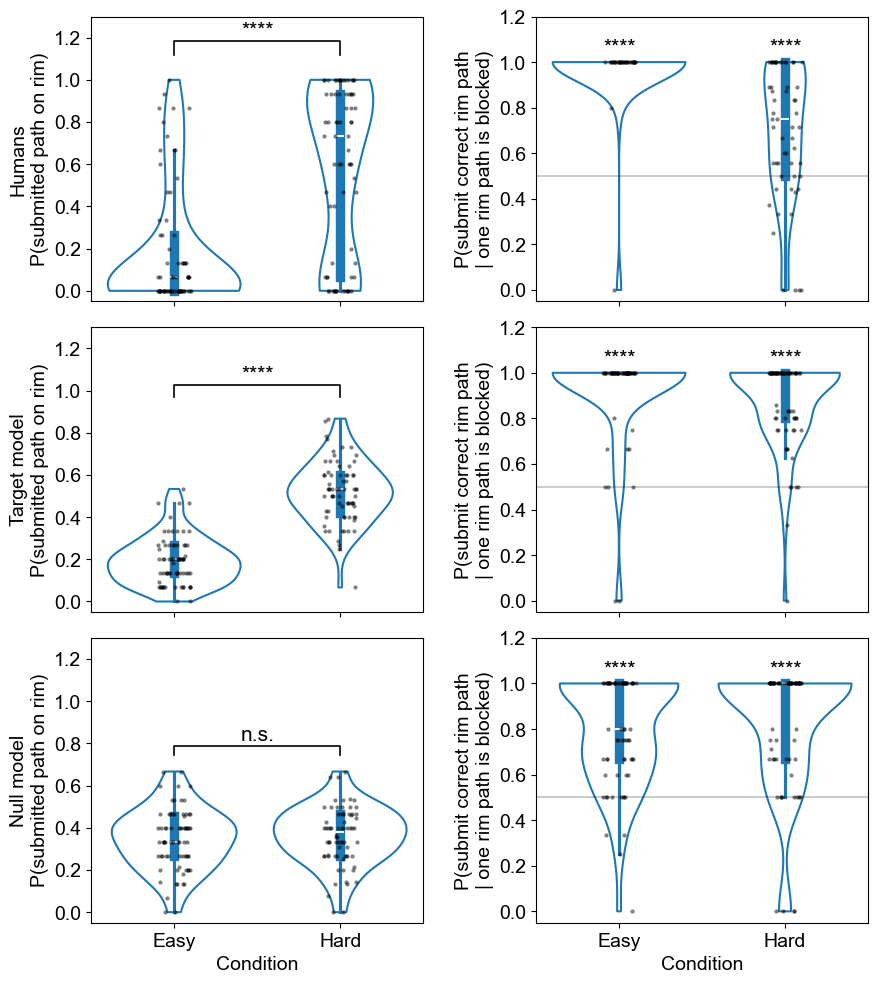

In [29]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["font.size"] = 14

cut = 0
inner = "box"
cond_order = [0, 1]

fig, ax = plt.subplots(
    3, 2,
    figsize=(9, 10),
    sharex=True,
    sharey=False,
)


# ============================================================
# Row 1: Humans
# ============================================================

sns.violinplot(
    data=df_human_p_rim,
    x="cond",
    y="human_p_rim",
    order=cond_order,
    cut=cut,
    inner=inner,
    fill=False,
    ax=ax[0, 0],
)

sns.stripplot(
    data=df_human_p_rim,
    x="cond",
    y="human_p_rim",
    order=cond_order,
    color="k",
    alpha=0.5,
    size=3,
    legend=False,
    ax=ax[0, 0],
)

annotate_paired(
    ax=ax[0, 0],
    df=df_human_p_rim,
    x="cond",
    y="human_p_rim",
    hue=None,
    pairs=[(0, 1)],
    order=cond_order,
    text_offset=0.06,
)

ax[0, 0].set_xlim([-0.5, 1.5])
ax[0, 0].set_ylim([-0.05, 1.3])
ax[0, 0].set_ylabel("Humans\nP(submitted path on rim)")
ax[0, 0].set_xlabel("Condition")
ax[0, 0].set_xticks(np.arange(len(cond_order)))
ax[0, 0].set_xticklabels(["Easy", "Hard"])


sns.violinplot(
    data=df_human_correct_rim,
    x="cond",
    y="human_p_correct_given_rim",
    order=cond_order,
    cut=cut,
    inner=inner,
    fill=False,
    ax=ax[0, 1],
)

sns.stripplot(
    data=df_human_correct_rim,
    x="cond",
    y="human_p_correct_given_rim",
    order=cond_order,
    color="k",
    alpha=0.5,
    size=3,
    legend=False,
    ax=ax[0, 1],
)

reset_numeric_xticklabels_for_annotation(ax[0, 1], cond_order)

annotate_violin_significance(
    ax=ax[0, 1],
    df=df_human_correct_rim,
    x="cond",
    y="human_p_correct_given_rim",
    hue=None,
    test="t",
    mu=0.5,
    y_offset=0.02,
    min_height_pad=-0.1,
)

ax[0, 1].set_xticks(np.arange(len(cond_order)))
ax[0, 1].set_xticklabels(["Easy", "Hard"])
ax[0, 1].plot([-1, 2], [0.5, 0.5], "k-", alpha=0.2)
ax[0, 1].set_xlim([-0.5, 1.5])
ax[0, 1].set_ylim([-0.05, 1.20])
ax[0, 1].set_ylabel("P(submit correct rim path\n| one rim path is blocked)")
ax[0, 1].set_xlabel("Condition")


# ============================================================
# Helper for held-out model rows
# ============================================================

def plot_heldout_model_row_with_annotations(
    ax_row,
    model_name,
    df_model_p_rim,
    df_model_correct_rim,
):
    # --------------------------------------------------------
    # Column 1: P(path on rim)
    # --------------------------------------------------------
    df_panel1 = df_model_p_rim[
        df_model_p_rim["model"] == model_name
    ].copy()

    sns.violinplot(
        data=df_panel1,
        x="cond",
        y="model_p_rim",
        order=cond_order,
        cut=cut,
        inner=inner,
        fill=False,
        ax=ax_row[0],
    )

    sns.stripplot(
        data=df_panel1,
        x="cond",
        y="model_p_rim",
        order=cond_order,
        color="k",
        alpha=0.5,
        size=3,
        legend=False,
        ax=ax_row[0],
    )

    annotate_paired(
        ax=ax_row[0],
        df=df_panel1,
        x="cond",
        y="model_p_rim",
        hue=None,
        pairs=[(0, 1)],
        order=cond_order,
        text_offset=0.06,
    )

    ax_row[0].set_xlim([-0.5, 1.5])
    ax_row[0].set_ylim([-0.05, 1.3])
    ax_row[0].set_ylabel(
        f"{model_name} model\nP(submitted path on rim)"
    )
    ax_row[0].set_xlabel("Condition")
    ax_row[0].set_xticks(np.arange(len(cond_order)))
    ax_row[0].set_xticklabels(["Easy", "Hard"])

    # --------------------------------------------------------
    # Column 2: P(correct rim | rim chosen, one rim blocked)
    # --------------------------------------------------------
    df_panel2 = df_model_correct_rim[
        df_model_correct_rim["model"] == model_name
    ].copy()

    sns.violinplot(
        data=df_panel2,
        x="cond",
        y="model_p_correct_given_rim",
        order=cond_order,
        cut=cut,
        inner=inner,
        fill=False,
        ax=ax_row[1],
    )

    sns.stripplot(
        data=df_panel2,
        x="cond",
        y="model_p_correct_given_rim",
        order=cond_order,
        color="k",
        alpha=0.5,
        size=3,
        legend=False,
        ax=ax_row[1],
    )

    reset_numeric_xticklabels_for_annotation(ax_row[1], cond_order)

    annotate_violin_significance(
        ax=ax_row[1],
        df=df_panel2,
        x="cond",
        y="model_p_correct_given_rim",
        hue=None,
        test="t",
        mu=0.5,
        y_offset=0.02,
        min_height_pad=-0.1,
    )

    ax_row[1].set_xticks(np.arange(len(cond_order)))
    ax_row[1].set_xticklabels(["Easy", "Hard"])
    ax_row[1].plot([-1, 2], [0.5, 0.5], "k-", alpha=0.2)
    ax_row[1].set_xlim([-0.5, 1.5])
    ax_row[1].set_ylim([-0.05, 1.20])
    ax_row[1].set_ylabel(
        "P(submit correct rim path\n| one rim path is blocked)"
    )
    ax_row[1].set_xlabel("Condition")


# ============================================================
# Row 2: Target
# Row 3: Null
# ============================================================

plot_heldout_model_row_with_annotations(
    ax_row=ax[1, :],
    model_name="Target",
    df_model_p_rim=df_model_p_rim_cv,
    df_model_correct_rim=df_model_correct_rim_cv,
)

plot_heldout_model_row_with_annotations(
    ax_row=ax[2, :],
    model_name="Null",
    df_model_p_rim=df_model_p_rim_cv,
    df_model_correct_rim=df_model_correct_rim_cv,
)


fig.tight_layout()

plt.savefig(
    os.path.join(figpath, f"exp1_humans_target_null_3x2_heldout_cv_{PRED_MODE}_{PARTICIPANT_MODE}.pdf"),
    bbox_inches="tight"
)

plt.show()